### Инициализация проекта

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [109]:
data = pd.read_csv('data/smoke_detector_task.csv')

### Исследование исходных данных

In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62484 non-null  float64
 3   Humidity[%]     62383 non-null  float64
 4   TVOC[ppb]       62009 non-null  float64
 5   eCO2[ppm]       62305 non-null  float64
 6   Raw H2          62519 non-null  float64
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62603 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62313 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62378 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  object 
dtypes: float64(11), int64(4), object(1)
memory usage: 7.6+ MB


2 лишних поля: "Unnamed: 0" и "CNT" - не несут никакой смысловой нагрузки, "CNT" - просто счётчик от 1 и до длины датасета

In [111]:
data = data.drop("Unnamed: 0", axis=1)
data = data.drop("CNT", axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62630 non-null  int64  
 1   Temperature[C]  62484 non-null  float64
 2   Humidity[%]     62383 non-null  float64
 3   TVOC[ppb]       62009 non-null  float64
 4   eCO2[ppm]       62305 non-null  float64
 5   Raw H2          62519 non-null  float64
 6   Raw Ethanol     62630 non-null  int64  
 7   Pressure[hPa]   62603 non-null  float64
 8   PM1.0           62630 non-null  float64
 9   PM2.5           62313 non-null  float64
 10  NC0.5           62630 non-null  float64
 11  NC1.0           62378 non-null  float64
 12  NC2.5           62630 non-null  float64
 13  Fire Alarm      62630 non-null  object 
dtypes: float64(11), int64(2), object(1)
memory usage: 6.7+ MB


In [112]:
data.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,6.263000e+04,62484.000000,62383.000000,62009.000000,62305.000000,62519.000000,62630.000000,62603.000000,62630.000000,62313.000000,62630.000000,62378.000000,62630.000000
mean,1.654792e+09,15.972252,48.536969,1944.124030,670.574994,12942.383835,19754.257912,938.627644,100.594309,184.443467,491.463608,203.382660,80.049042
std,1.100025e+05,14.361206,8.868993,7819.668069,1909.675941,272.531480,609.513156,1.331169,922.524245,1976.590473,4265.661251,2214.719662,1083.383189
min,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.654743e+09,11.000500,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000
50%,1.654762e+09,20.130000,50.140000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.942000,0.044000
75%,1.654778e+09,25.410000,53.240000,1189.000000,438.000000,13108.000000,20078.000000,939.417000,2.090000,2.180000,14.420000,2.249000,0.051000
max,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000


In [113]:
data.head(20)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,1654733331,20.000,57.36,0.0,400.0,12306.0,18520,939.735,0.00,0.00,0.0,0.000,0.000,No
1,1654733332,20.015,56.67,0.0,400.0,12345.0,18651,939.744,0.00,0.00,0.0,0.000,0.000,No
2,1654733333,20.029,55.96,0.0,400.0,12374.0,18764,939.738,0.00,0.00,0.0,0.000,0.000,No
3,1654733334,20.044,55.28,0.0,400.0,12390.0,18849,939.736,0.00,0.00,0.0,0.000,0.000,No
4,1654733335,20.059,54.69,0.0,400.0,12403.0,18921,939.744,0.00,0.00,0.0,0.000,0.000,No
5,1654733336,20.073,54.12,0.0,400.0,12419.0,18998,939.725,0.00,0.00,0.0,0.000,0.000,No
6,1654733337,20.088,53.61,0.0,400.0,12432.0,19058,939.738,0.00,0.00,0.0,0.000,0.000,No
7,1654733338,20.103,53.20,0.0,400.0,12439.0,19114,939.758,0.00,0.00,0.0,0.000,0.000,No
8,1654733339,20.117,52.81,0.0,400.0,12448.0,19155,939.758,0.00,0.00,0.0,0.000,0.000,No
9,1654733340,20.132,52.46,0.0,400.0,12453.0,19195,939.756,0.90,3.78,0.0,4.369,2.780,No


<font size=4>
Датасет содержит следующие поля:

- `UTC` — время
- `Temperature[C]` — температура
- `Humidity[%]` — влажность
- `TVOC[ppb]` — содержание летучих органических соединений в воздухе и показания в виде концентрации TVOC - в частях на миллиард (ppb)
- `eCO2[ppm]` — концентрация молекул углекислого газа (CO2) в воздухе
- `Raw H2` — концентрации водорода (H₂)
- `Raw Ethanol` — сырое (необработанное) значение концентрации этанола (C₂H₅OH)
- `Pressure[hPa]` — давление воздуха, измеряемое в гектопаскалях (hPa)
- `PM1.0` — твёрдые частицы в воздухе ≤ 1.0 мкм (ультрамелкие частицы)
- `PM2.5` — частицы ≤ 2.5 мкм (мелкие частицы, опасные для здоровья)
- `NC0.5` — количество частиц определённого размера, концентрация частиц ≤ 0.5 мкм
- `NC1.0` — концентрация частиц ≤ 1.0 мкм
- `NC2.5` — концентрация частиц ≤ 2.5 мкм
- `Fire Alarm` — сработал ли датчик
</font>

Заключение по исходным данным:
- поле "Fire Alarm" следует перевести из типа object в тип bool
- поля "TVOC[ppb]", "eCO2[ppm]", "Raw H2" следует перевести из типа float в тип int
- "UTC" перевести в datetime

### Заполнение пропусков

In [114]:
(data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)

TVOC[ppb]         0.991538
eCO2[ppm]         0.518921
PM2.5             0.506147
NC1.0             0.402363
Humidity[%]       0.394380
Temperature[C]    0.233115
Raw H2            0.177231
Pressure[hPa]     0.043110
UTC               0.000000
Raw Ethanol       0.000000
PM1.0             0.000000
NC0.5             0.000000
NC2.5             0.000000
Fire Alarm        0.000000
dtype: float64

Функция для поиска похожих значений

In [115]:
def filler(row, feature):
    if pd.isna(row[feature]):
        similar = data[(abs(data["Temperature[C]"] - row["Temperature[C]"]) < 1) &
                       (abs(data["Humidity[%]"] - row["Humidity[%]"]) < 1) &
                       (abs(data["Raw Ethanol"] - row["Raw Ethanol"]) < 50) &
                       (abs(data["PM1.0"] - row["PM1.0"]) < 0.3) &
                       (abs(data["NC2.5"] - row["NC2.5"])) < 0.3].dropna(subset=[feature])
        if not similar.empty:
            return similar[feature].iloc[0]
    return row[feature]

In [116]:
def filler_special(row, feature):
    if pd.isna(row[feature]):
        similar = data[(abs(data["TVOC[ppb]"] - row["TVOC[ppb]"]) < 1) &
                       (abs(data["eCO2[ppm]"] - row["eCO2[ppm]"]) < 1) &
                       (abs(data["Raw Ethanol"] - row["Raw Ethanol"]) < 1) &
                       (abs(data["PM1.0"] - row["PM1.0"]) < 1) &
                       (abs(data["NC2.5"] - row["NC2.5"])) < 1].dropna(subset=[feature])
        if not similar.empty:
            return similar[feature].iloc[0]
    return row[feature]

Список полей, которые имеют пропуски

In [117]:
omissions = ["TVOC[ppb]", "eCO2[ppm]", "PM2.5", "NC1.0", "Raw H2", "Pressure[hPa]"]

In [118]:
ommisions_special = ["Temperature[C]", "Humidity[%]"]

### Заполнение всех пропусков схожими данными

In [119]:
for ommision in omissions:
    data[ommision] = data.apply(lambda row: filler(row, ommision), axis=1)

In [120]:
for ommision in ommisions_special:
    data[ommision] = data.apply(lambda row: filler_special(row, ommision), axis=1)

In [121]:
(data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)

UTC               0.0
Temperature[C]    0.0
Humidity[%]       0.0
TVOC[ppb]         0.0
eCO2[ppm]         0.0
Raw H2            0.0
Raw Ethanol       0.0
Pressure[hPa]     0.0
PM1.0             0.0
PM2.5             0.0
NC0.5             0.0
NC1.0             0.0
NC2.5             0.0
Fire Alarm        0.0
dtype: float64

### Исправление типов данных

In [122]:
data['TVOC[ppb]'] = data['TVOC[ppb]'].astype(int)
data['eCO2[ppm]'] = data['eCO2[ppm]'].astype(int)
data['Raw H2'] = data['Raw H2'].astype(int)

In [123]:
data["Fire Alarm"] = data["Fire Alarm"].map({"Yes": True, "No": False})

In [124]:
data["UTC"] = pd.to_datetime(data["UTC"], unit="s")

In [125]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   UTC             62630 non-null  datetime64[ns]
 1   Temperature[C]  62630 non-null  float64       
 2   Humidity[%]     62630 non-null  float64       
 3   TVOC[ppb]       62630 non-null  int64         
 4   eCO2[ppm]       62630 non-null  int64         
 5   Raw H2          62630 non-null  int64         
 6   Raw Ethanol     62630 non-null  int64         
 7   Pressure[hPa]   62630 non-null  float64       
 8   PM1.0           62630 non-null  float64       
 9   PM2.5           62630 non-null  float64       
 10  NC0.5           62630 non-null  float64       
 11  NC1.0           62630 non-null  float64       
 12  NC2.5           62630 non-null  float64       
 13  Fire Alarm      62630 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(8), int64(4)
me

### **Проверка "очищенных" данных**

In [126]:
data.duplicated().sum()

np.int64(0)

In [127]:
data.head(10)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,2022-06-09 00:08:51,20.000,57.36,0,400,12306,18520,939.735,0.0,0.00,0.0,0.000,0.00,False
1,2022-06-09 00:08:52,20.015,56.67,0,400,12345,18651,939.744,0.0,0.00,0.0,0.000,0.00,False
2,2022-06-09 00:08:53,20.029,55.96,0,400,12374,18764,939.738,0.0,0.00,0.0,0.000,0.00,False
3,2022-06-09 00:08:54,20.044,55.28,0,400,12390,18849,939.736,0.0,0.00,0.0,0.000,0.00,False
4,2022-06-09 00:08:55,20.059,54.69,0,400,12403,18921,939.744,0.0,0.00,0.0,0.000,0.00,False
5,2022-06-09 00:08:56,20.073,54.12,0,400,12419,18998,939.725,0.0,0.00,0.0,0.000,0.00,False
6,2022-06-09 00:08:57,20.088,53.61,0,400,12432,19058,939.738,0.0,0.00,0.0,0.000,0.00,False
7,2022-06-09 00:08:58,20.103,53.20,0,400,12439,19114,939.758,0.0,0.00,0.0,0.000,0.00,False
8,2022-06-09 00:08:59,20.117,52.81,0,400,12448,19155,939.758,0.0,0.00,0.0,0.000,0.00,False
9,2022-06-09 00:09:00,20.132,52.46,0,400,12453,19195,939.756,0.9,3.78,0.0,4.369,2.78,False


In [128]:
data.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,62630,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,2022-06-09 16:27:46.184272384,15.981641,48.571765,1924.847310,669.170924,12941.255964,19754.257912,938.628121,100.594309,183.509911,491.463608,202.564324,80.049042
min,2022-06-08 18:16:27,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-06-09 02:54:04.249999872,11.074000,47.540000,123.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.290000,8.820000,1.346000,0.033000
50%,2022-06-09 08:05:19.500000,20.108500,50.170000,958.000000,400.000000,12923.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.940000,0.044000
75%,2022-06-09 12:26:16.750000128,25.400000,53.260000,1187.000000,437.000000,13108.000000,20078.000000,939.419000,2.090000,2.180000,14.420000,2.247000,0.051000
max,2022-06-13 14:20:51,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000
std,NaN,14.345772,8.868743,7783.187445,1904.813775,273.602391,609.513156,1.331080,922.524245,1971.625265,4265.661251,2210.296992,1083.383189


# EDA

Поля, где явно выражены выбросы:
- TVOC[ppb]
- eCO2[ppm]
- PM1.0
- PM2.5	
- NC0.5	
- NC1.0
- NC2.5

In [129]:
data.describe()[['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']]

,TVOC[ppb],eCO2[ppm],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,1924.847310,669.170924,100.594309,183.509911,491.463608,202.564324,80.049042
min,0.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,123.000000,400.000000,1.280000,1.290000,8.820000,1.346000,0.033000
50%,958.000000,400.000000,1.810000,1.880000,12.450000,1.940000,0.044000
75%,1187.000000,437.000000,2.090000,2.180000,14.420000,2.247000,0.051000
max,60000.000000,60000.000000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000
std,7783.187445,1904.813775,922.524245,1971.625265,4265.661251,2210.296992,1083.383189


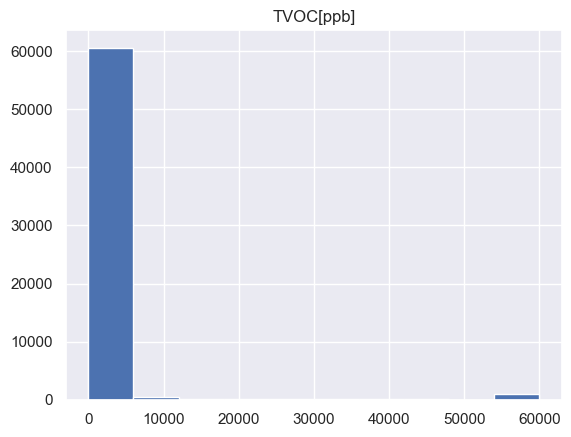

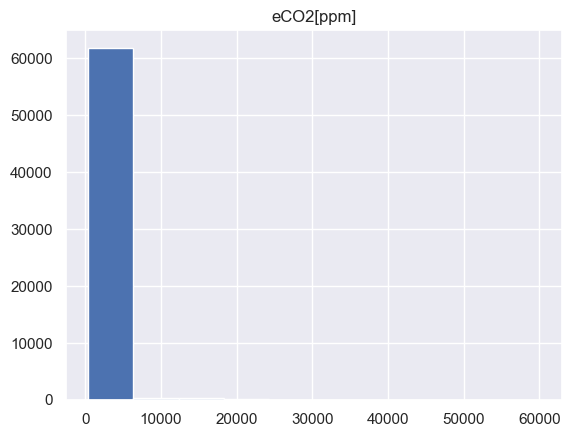

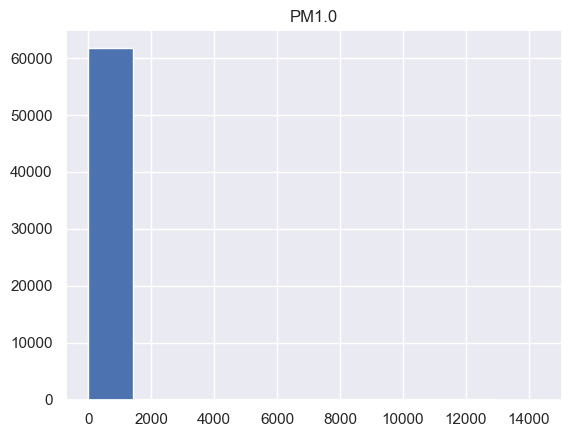

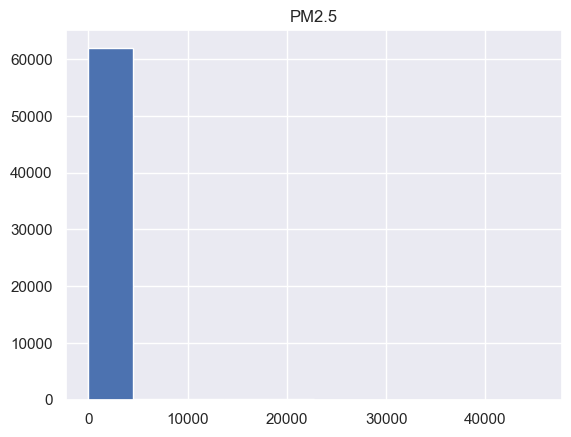

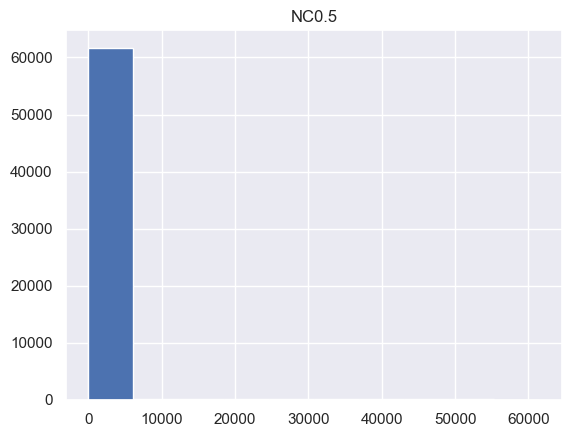

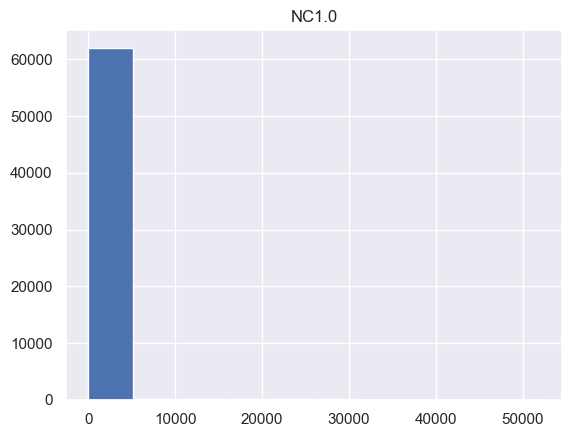

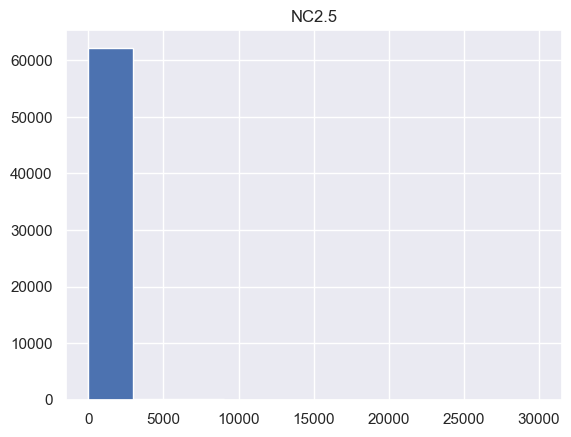

In [130]:
columns = ['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']

for column in columns:
    data.hist(column)

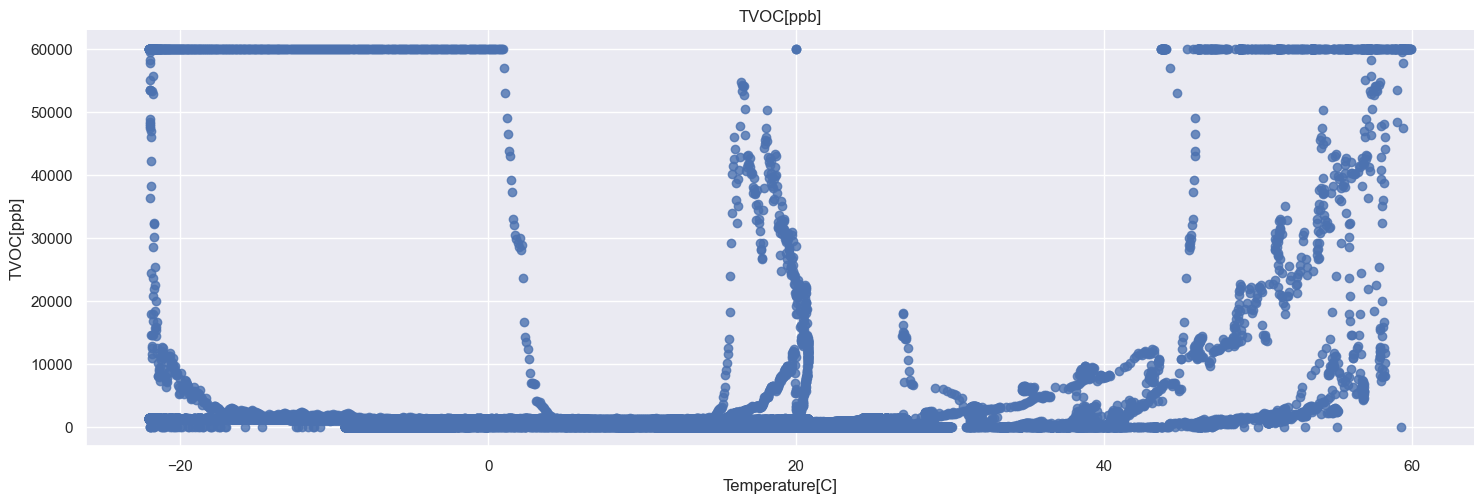

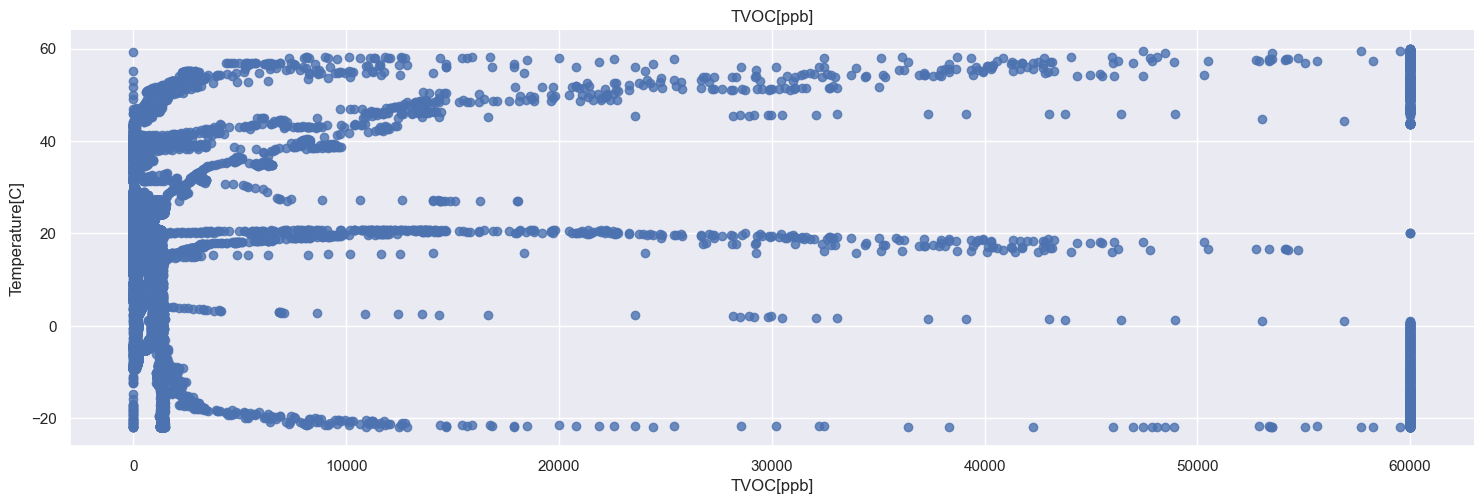

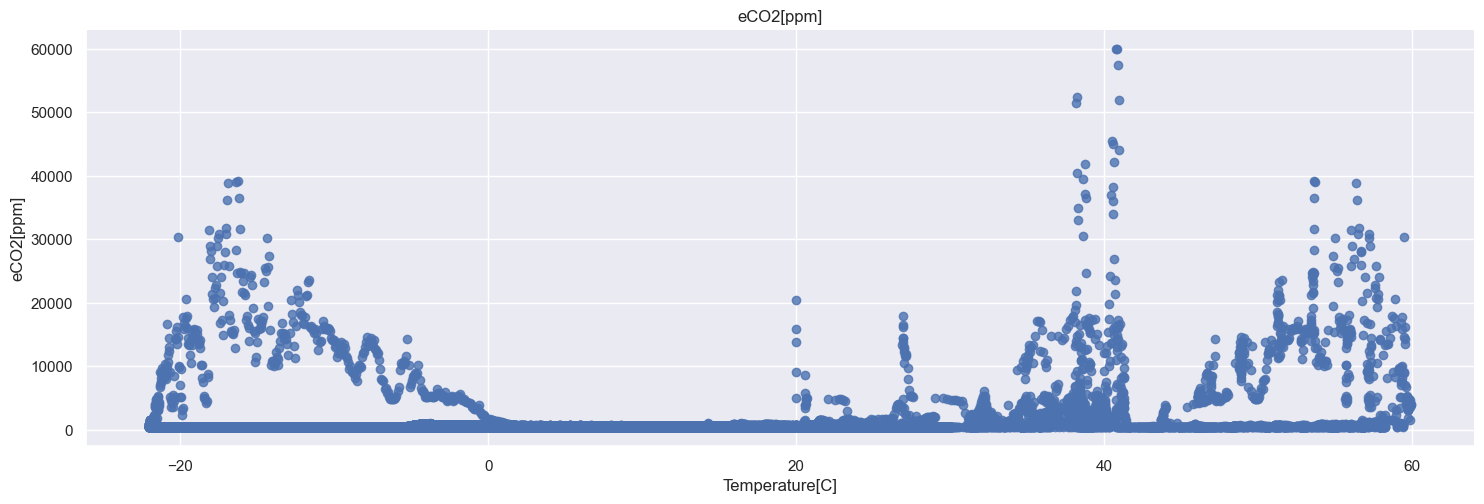

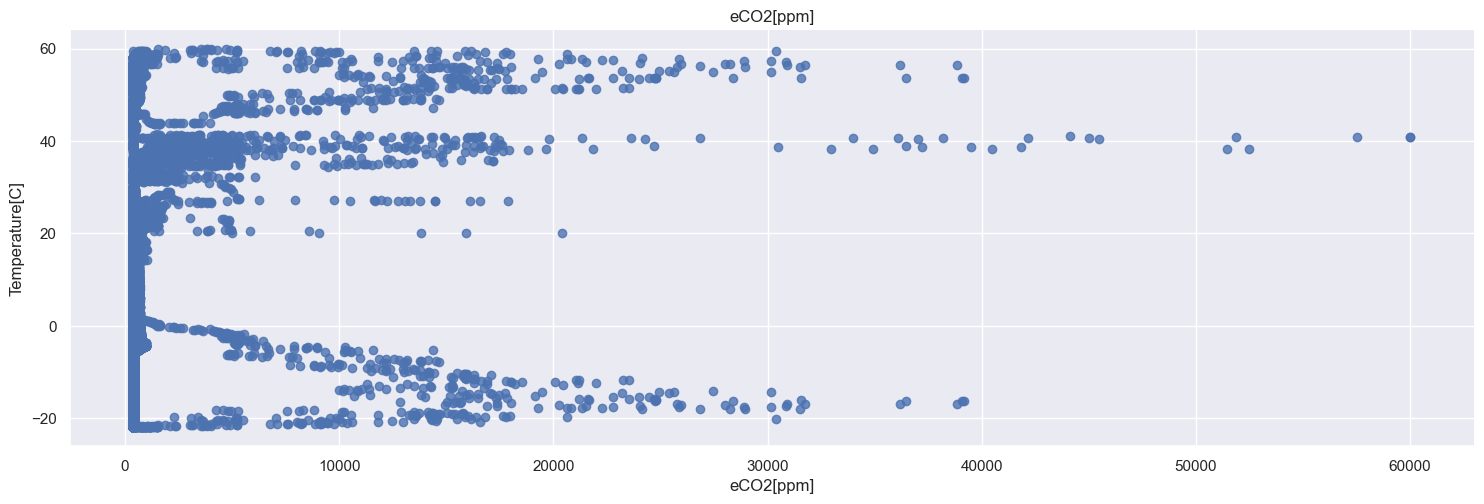

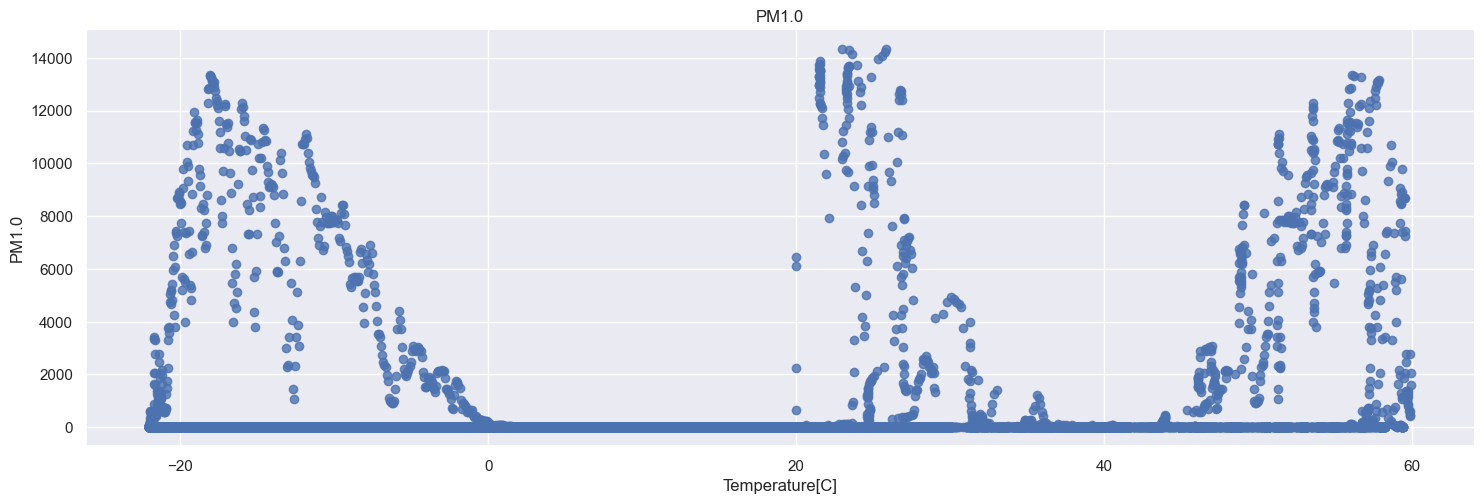

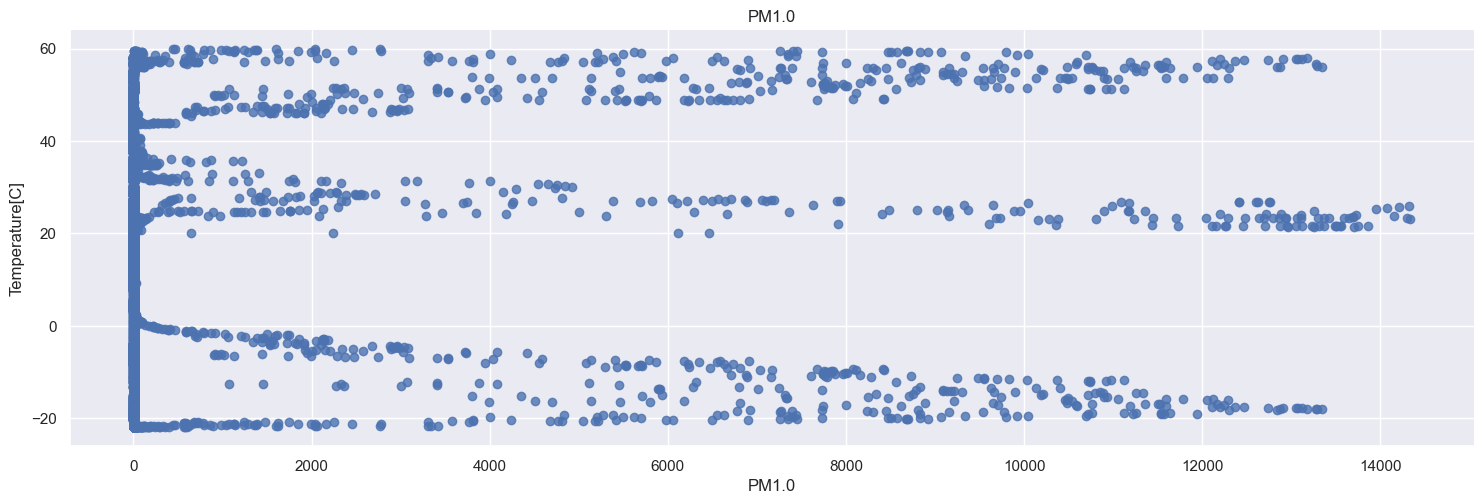

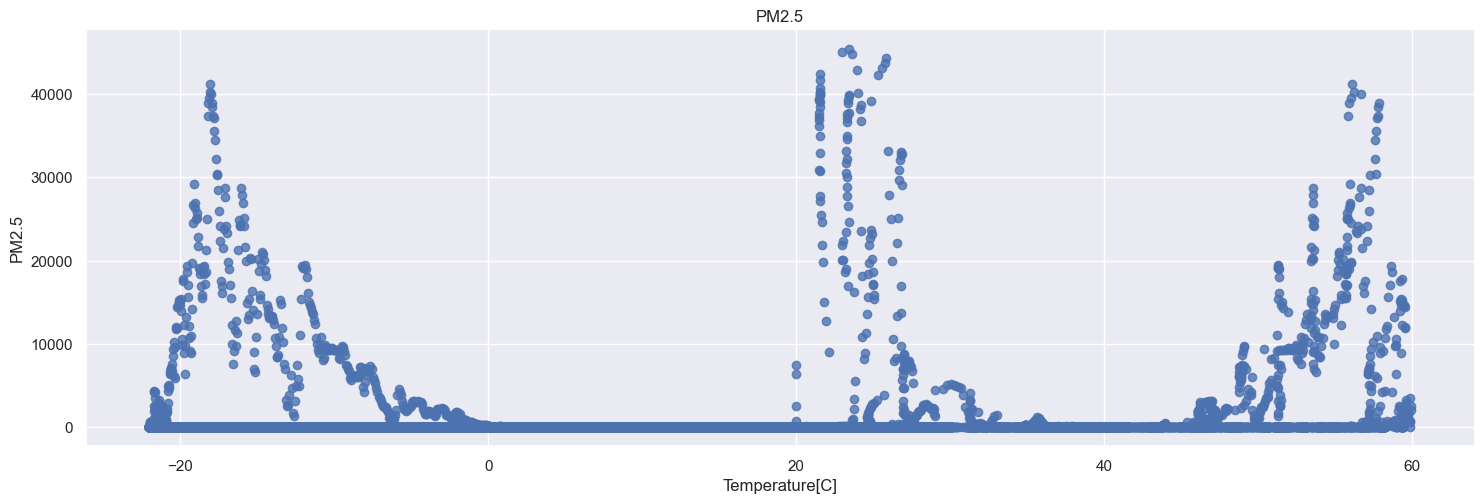

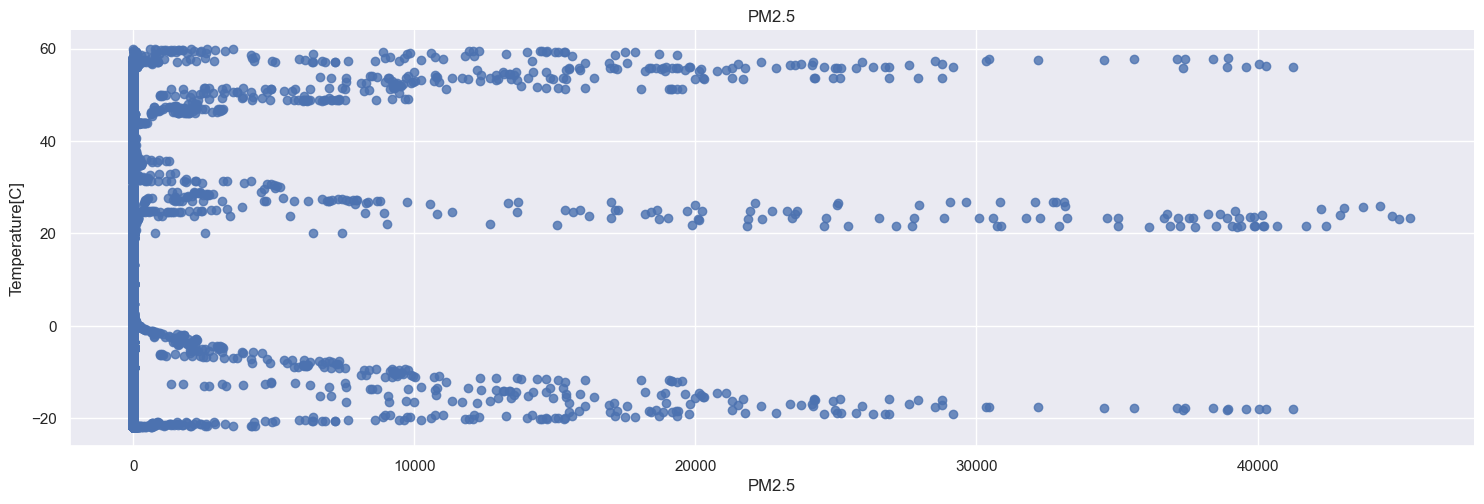

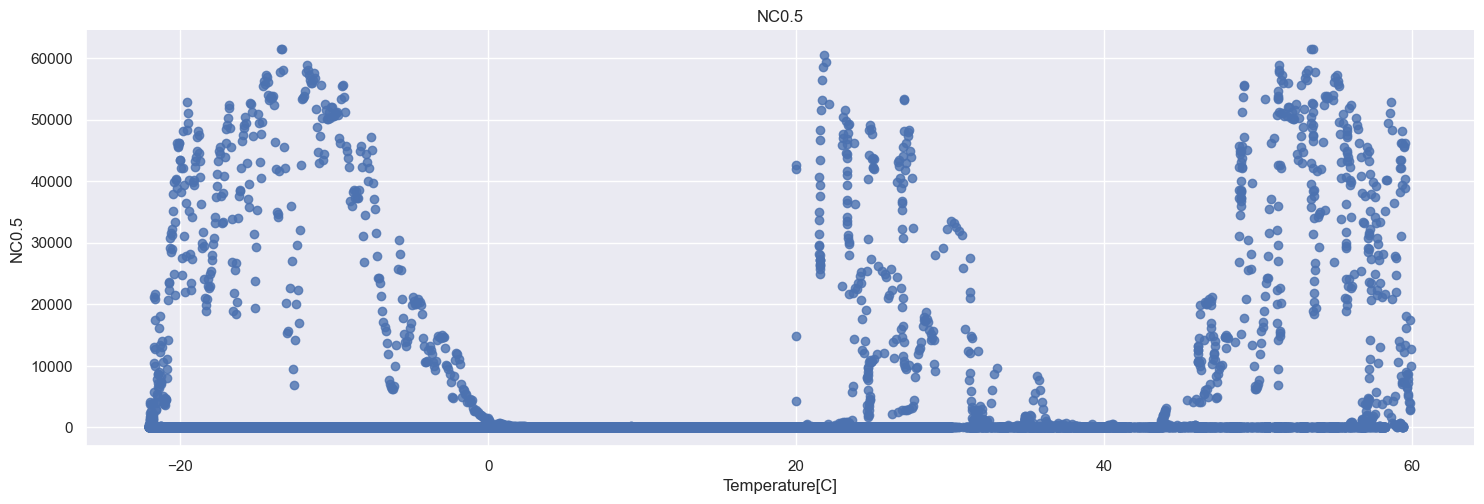

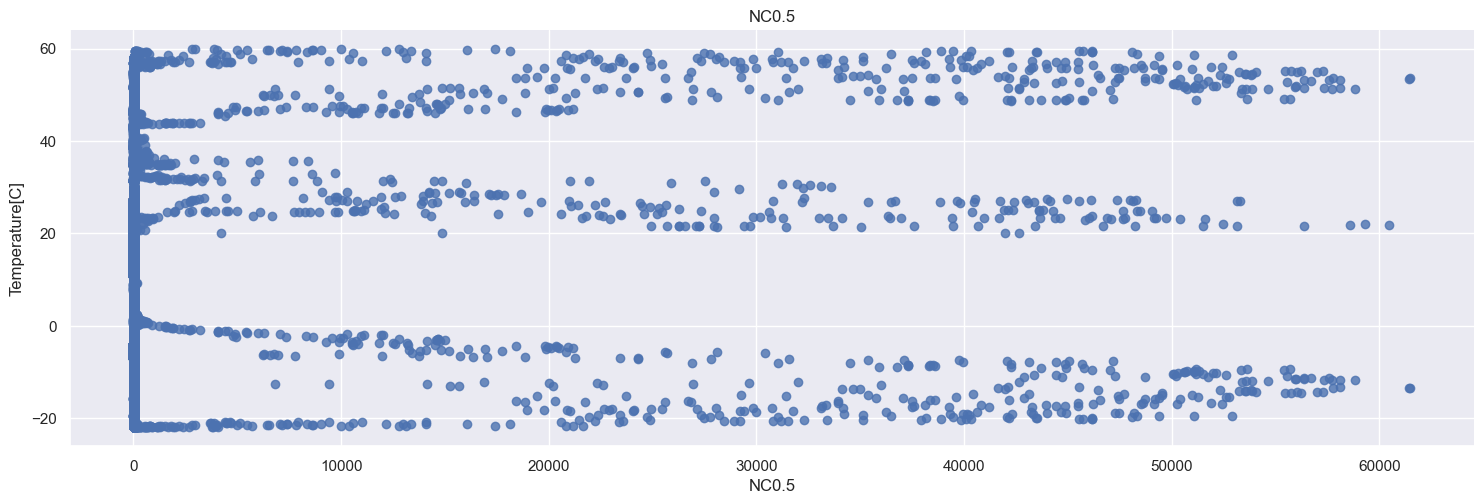

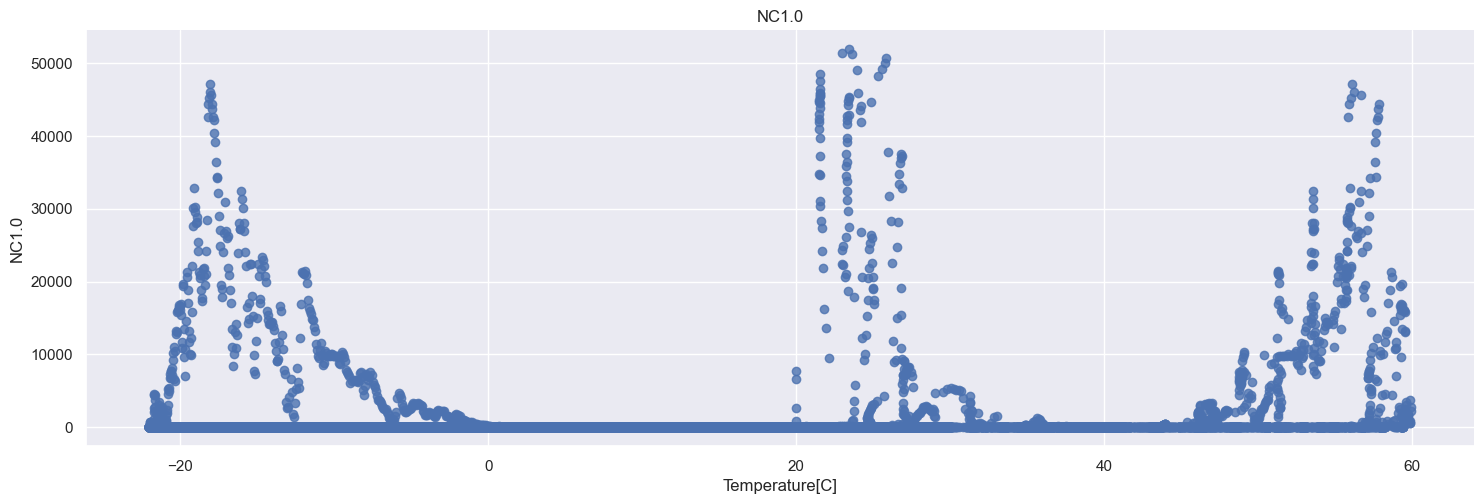

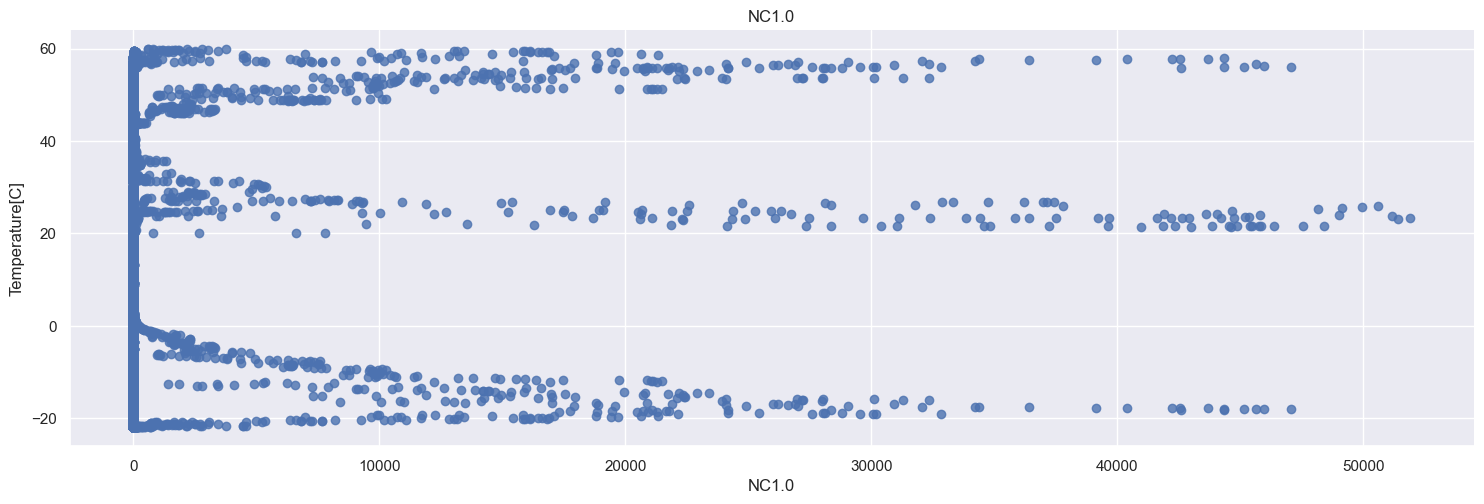

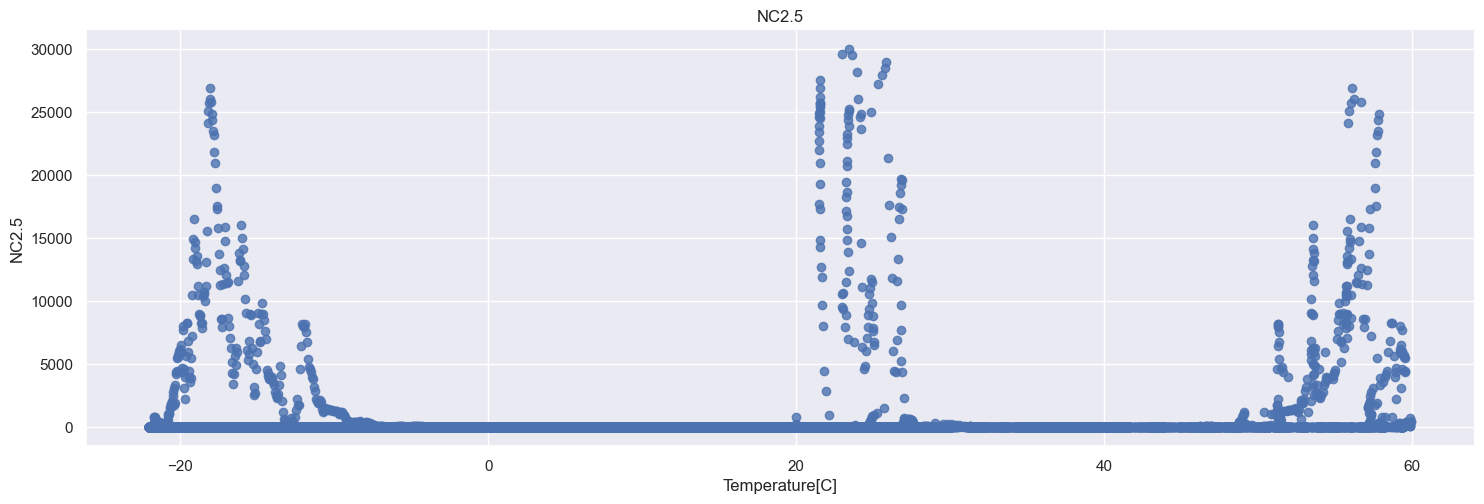

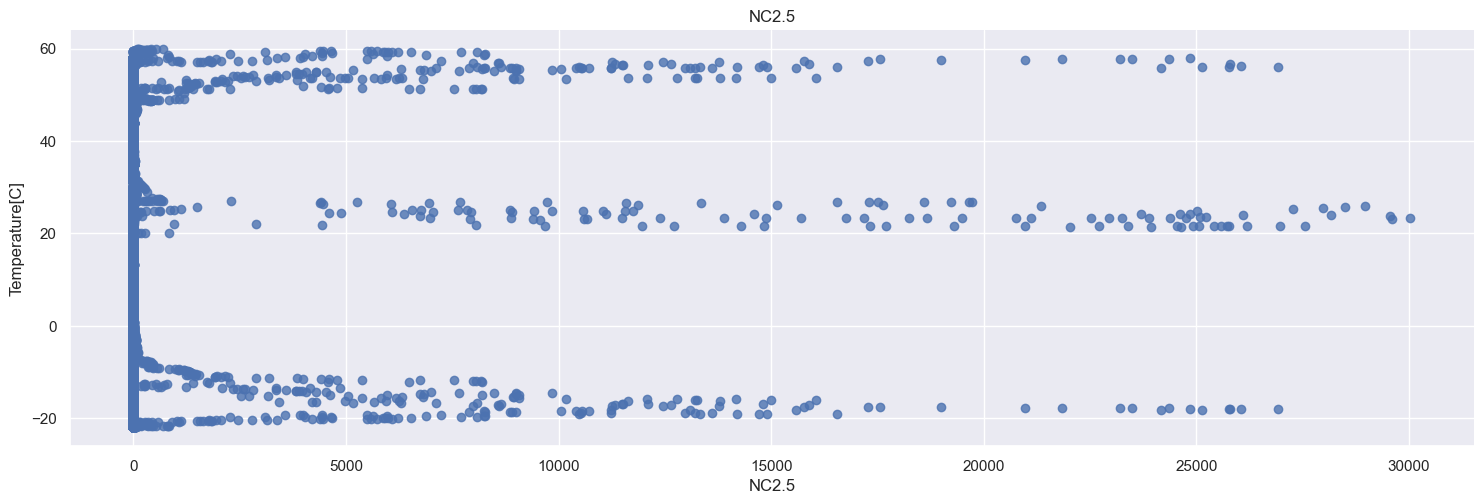

In [131]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=data, height = 5, aspect =3, fit_reg=False)
    plt.title(column)
    sns.lmplot(x=column, y="Temperature[C]", data=data, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

### Анализ данных в момент срабатывания датчика

In [132]:
fire_alarm_true = data[data["Fire Alarm"] == True]
fire_alarm_false = data[data["Fire Alarm"] == False]

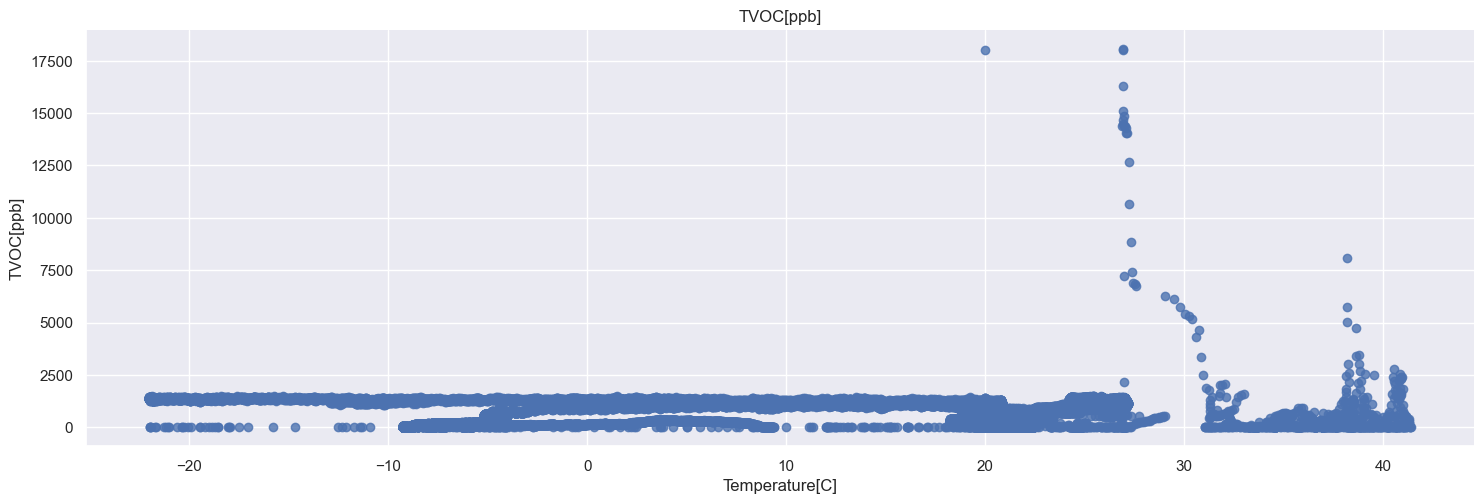

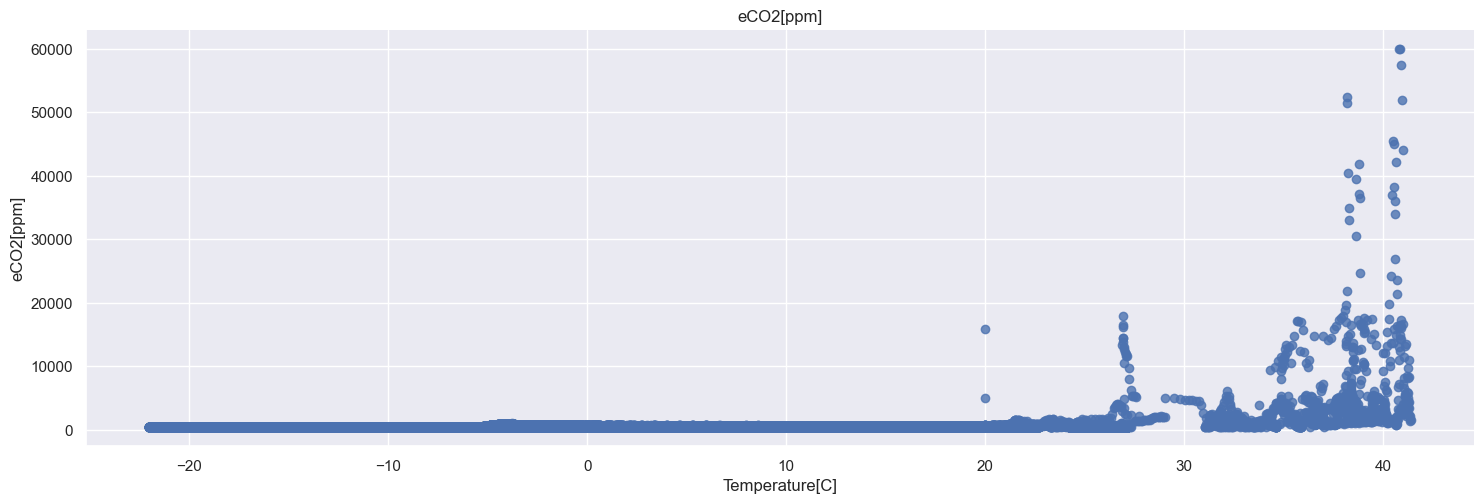

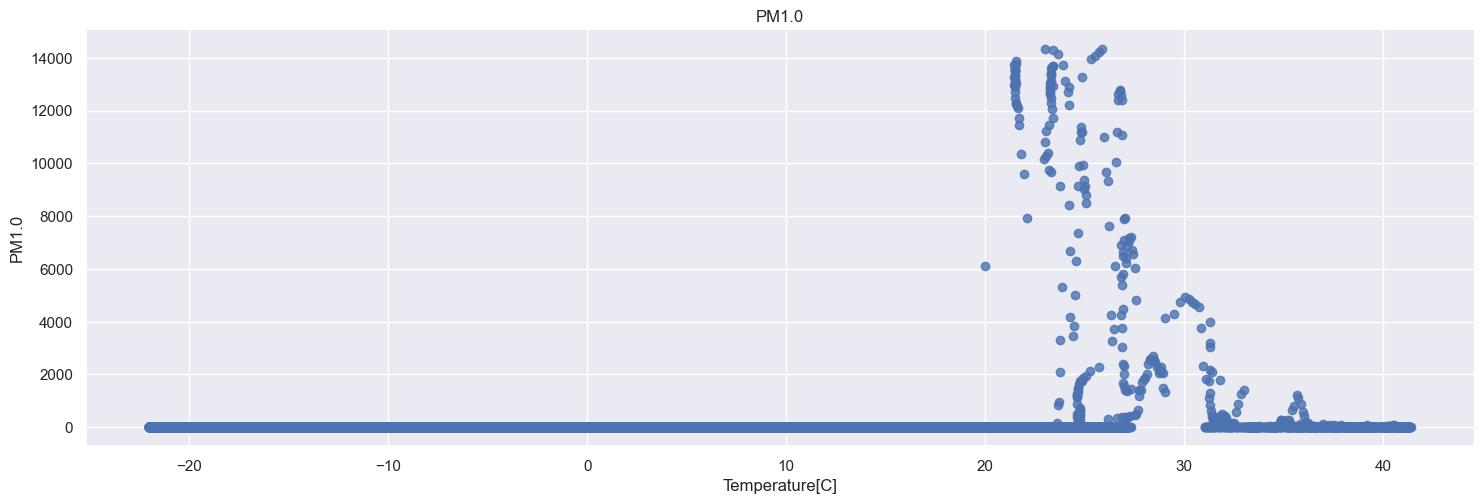

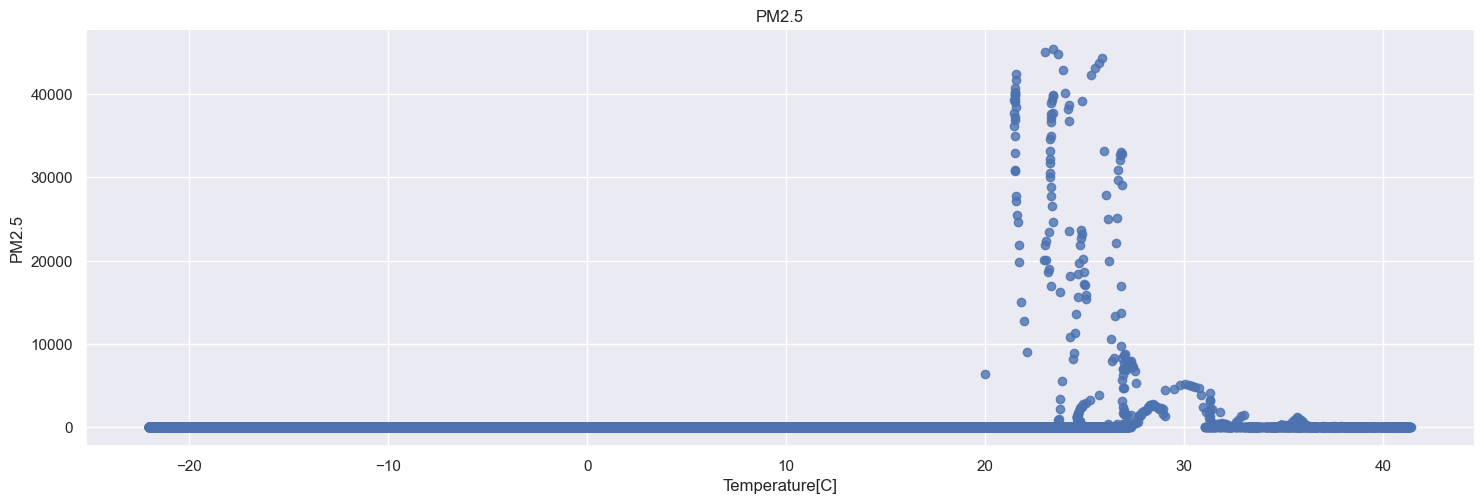

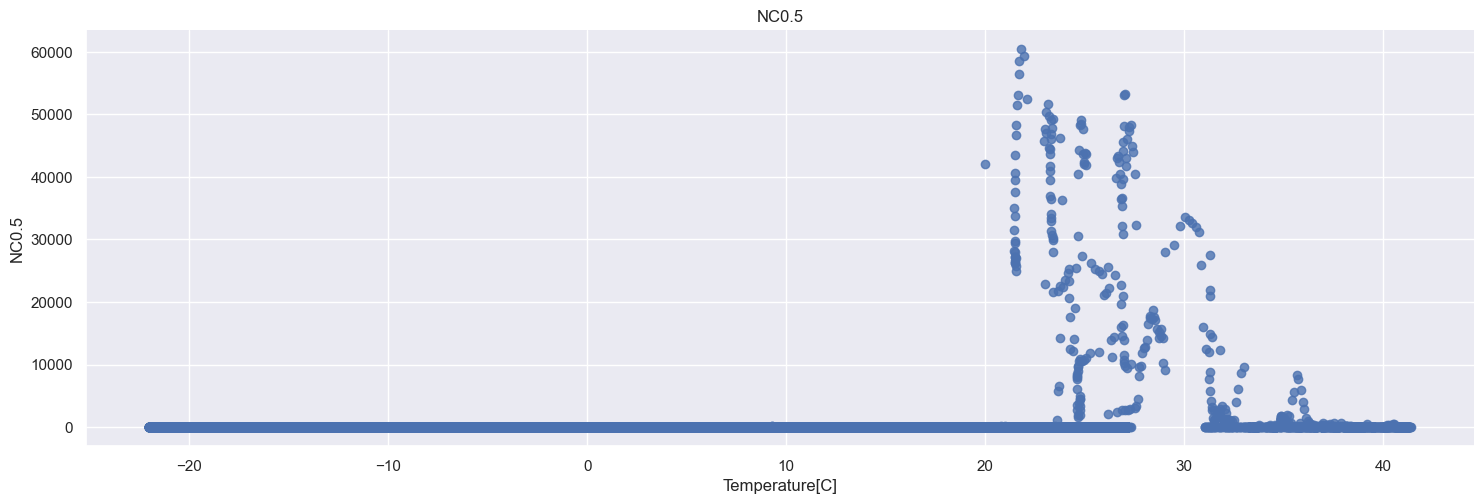

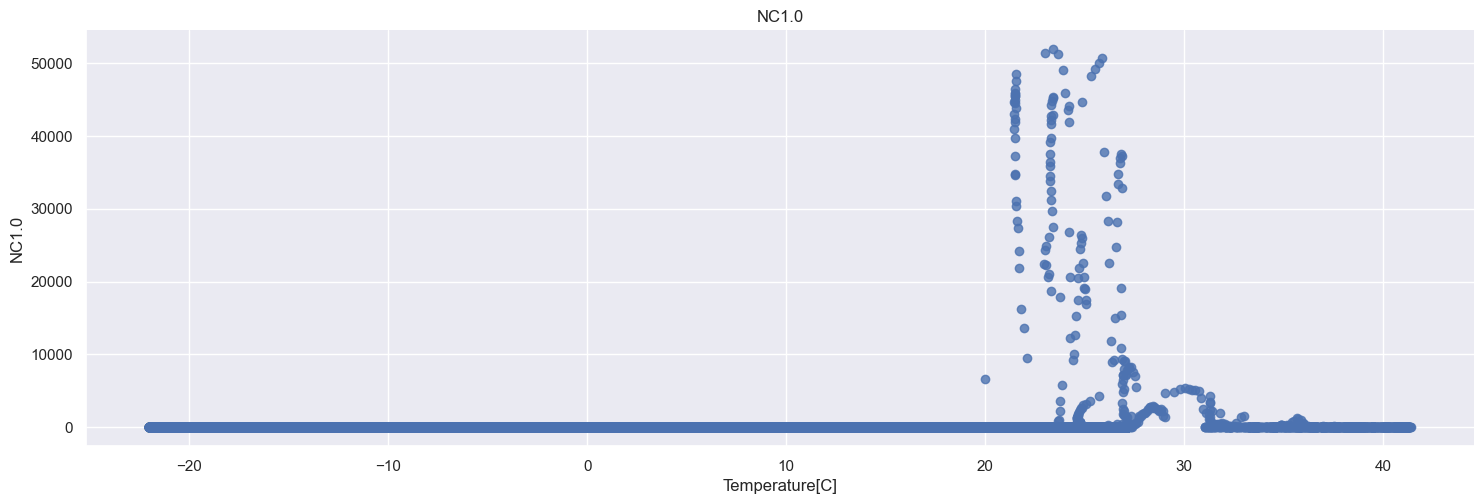

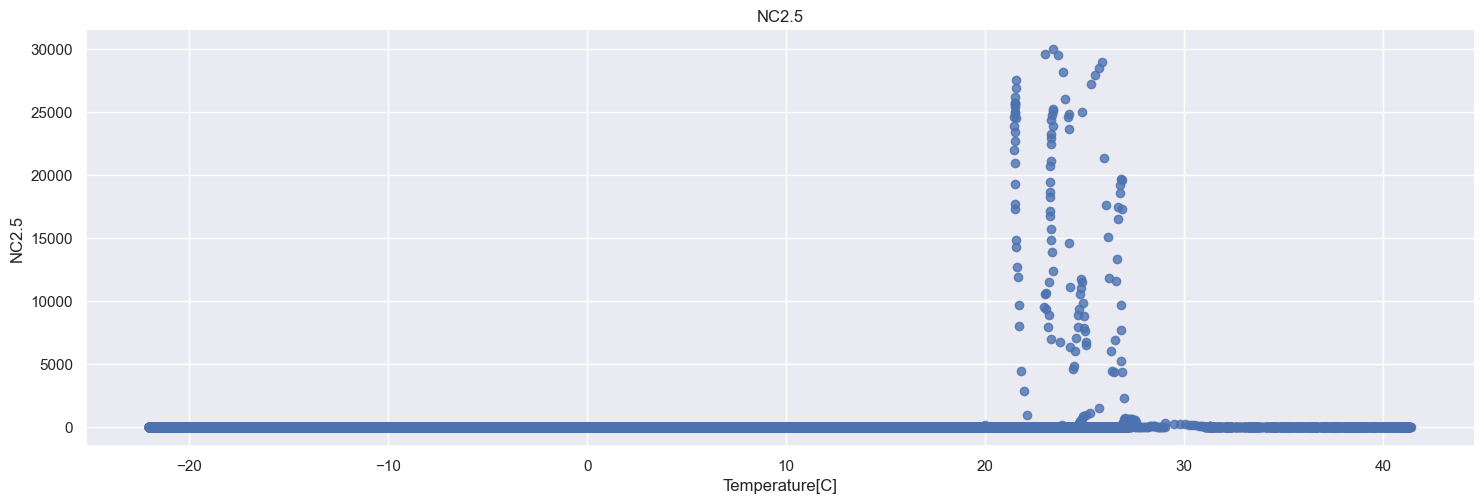

In [133]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=fire_alarm_true, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

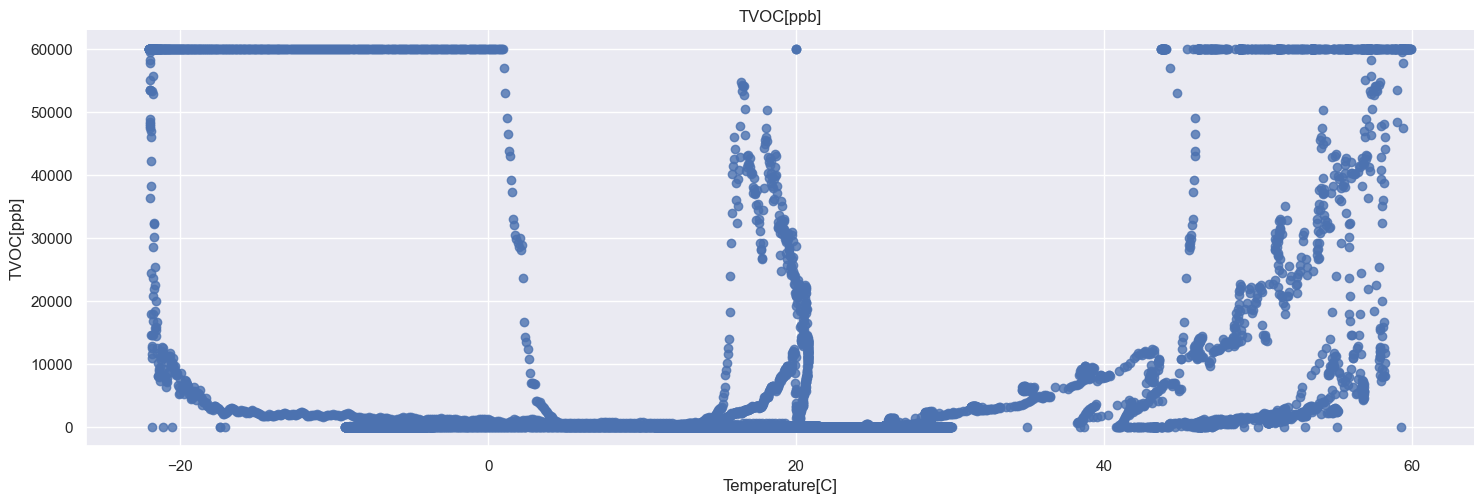

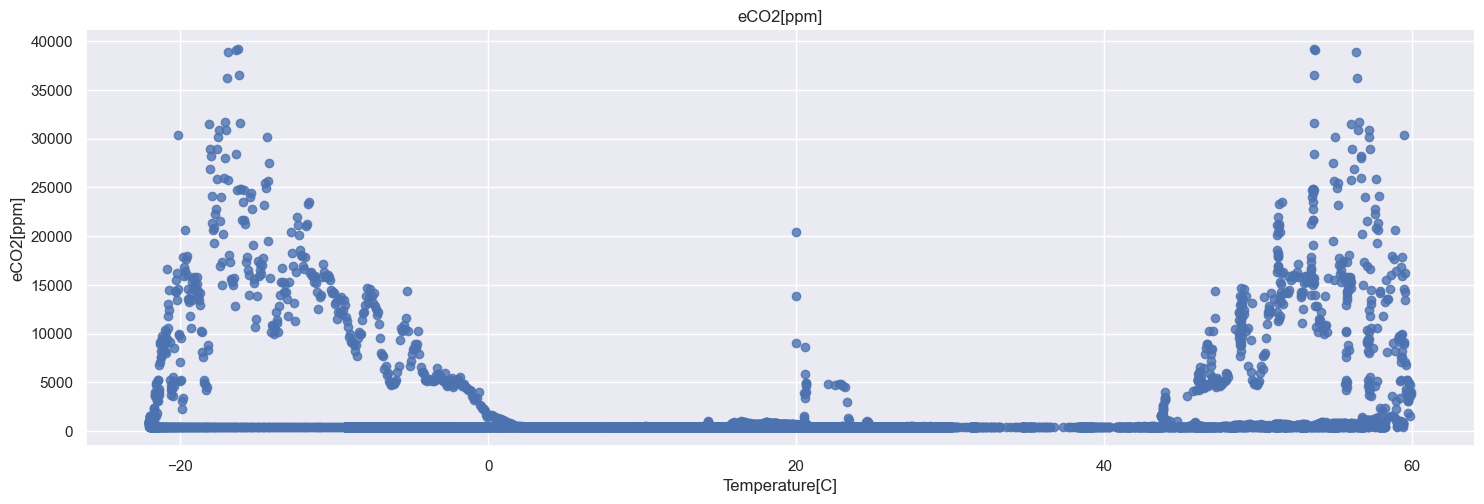

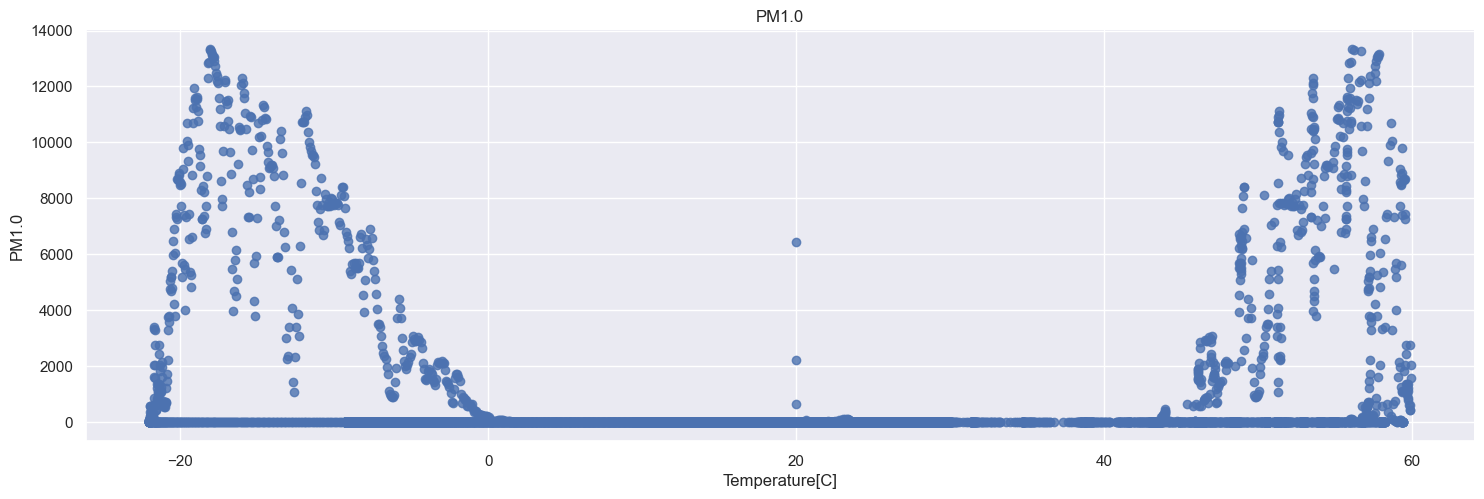

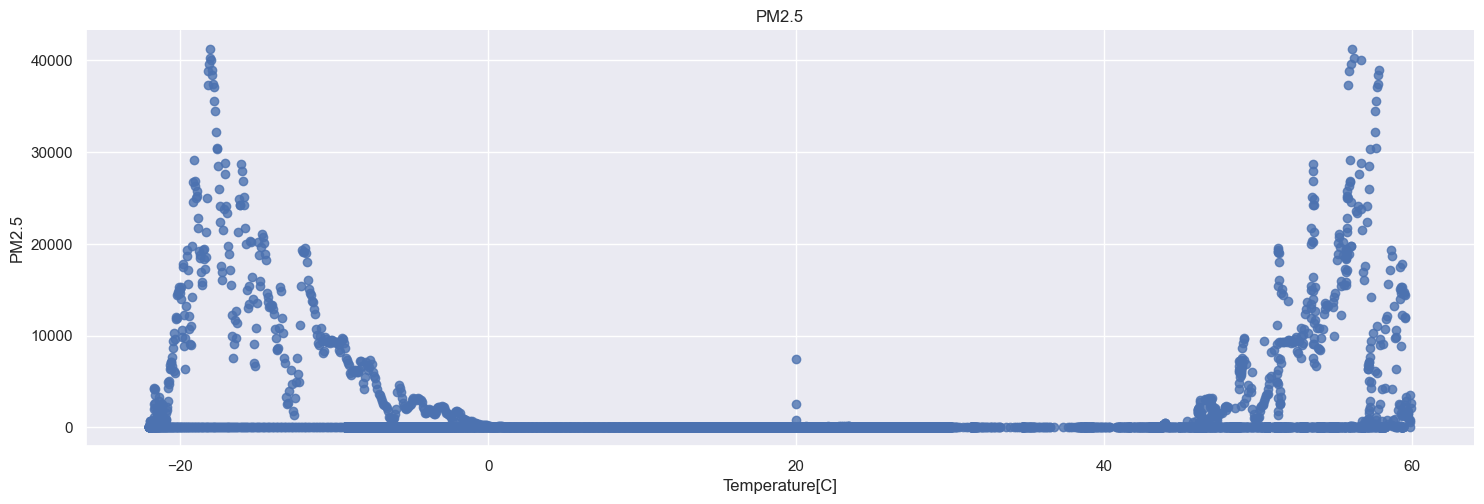

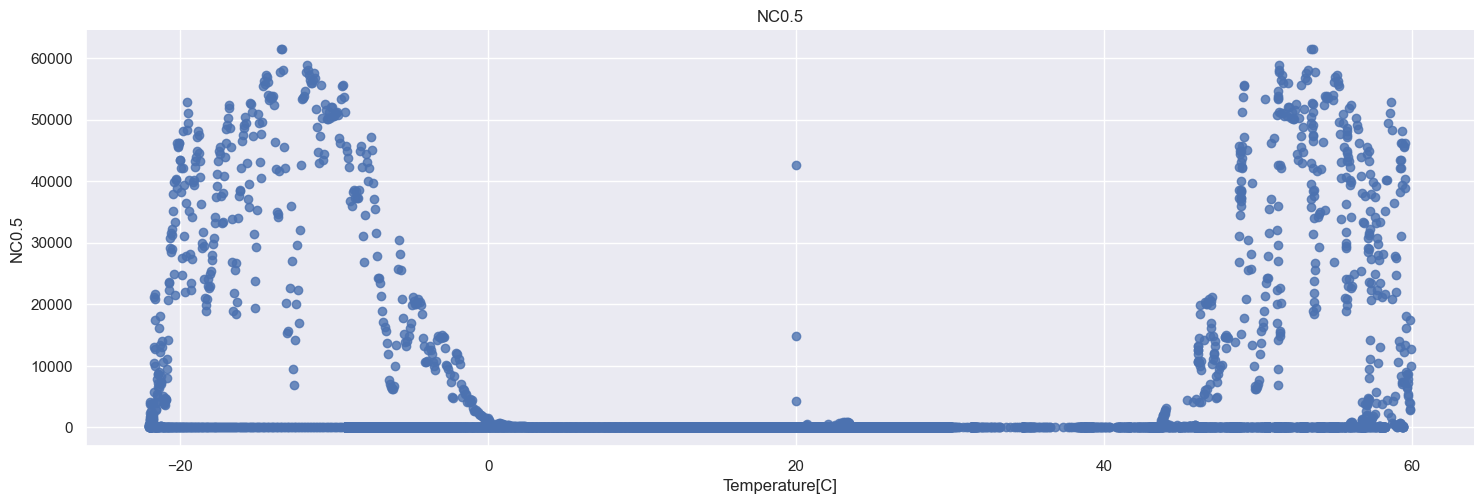

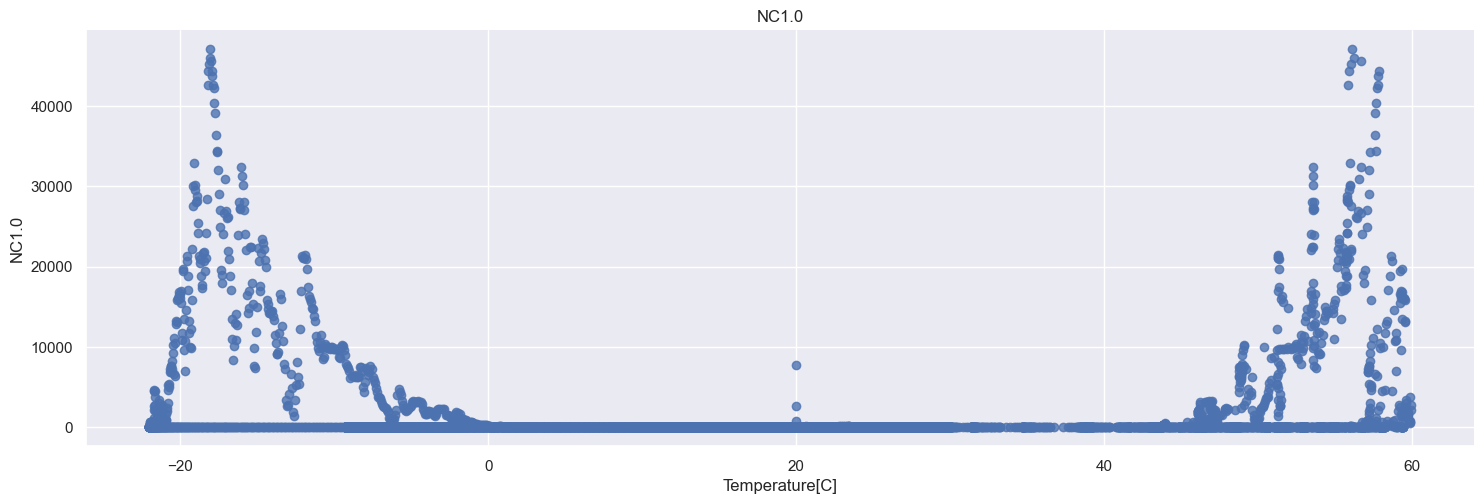

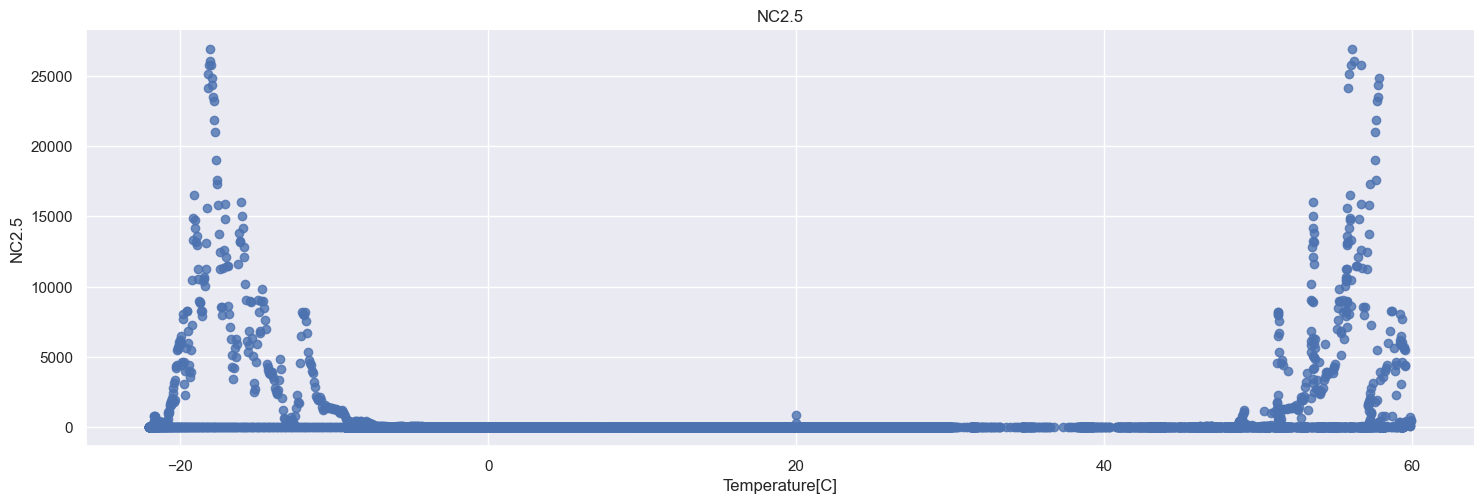

In [134]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=fire_alarm_false, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

In [135]:
def fixer(df, feature, upper_bound):
    def find_nearest_value(row):
        if row[feature] > upper_bound:
            similar = df[(abs(data["Temperature[C]"] - row["Temperature[C]"]) < 15) &
                         (abs(data["Humidity[%]"] - row["Humidity[%]"]) < 5) &
                         (df[feature] <= upper_bound)]

            if not similar.empty:
                return similar[feature].median()

        return row[feature]

    df[feature] = df.apply(find_nearest_value, axis=1)

    return df

In [136]:
emissions = {
    "TVOC[ppb]": 5000,
    "eCO2[ppm]": 5000,
    "PM1.0": 5,
    "PM2.5": 5,
    "NC0.5": 20,
    "NC1.0": 10,
    "NC2.5": 5,
}

In [137]:
for key in emissions:
    data = fixer(data, key, upper_bound=emissions[key])

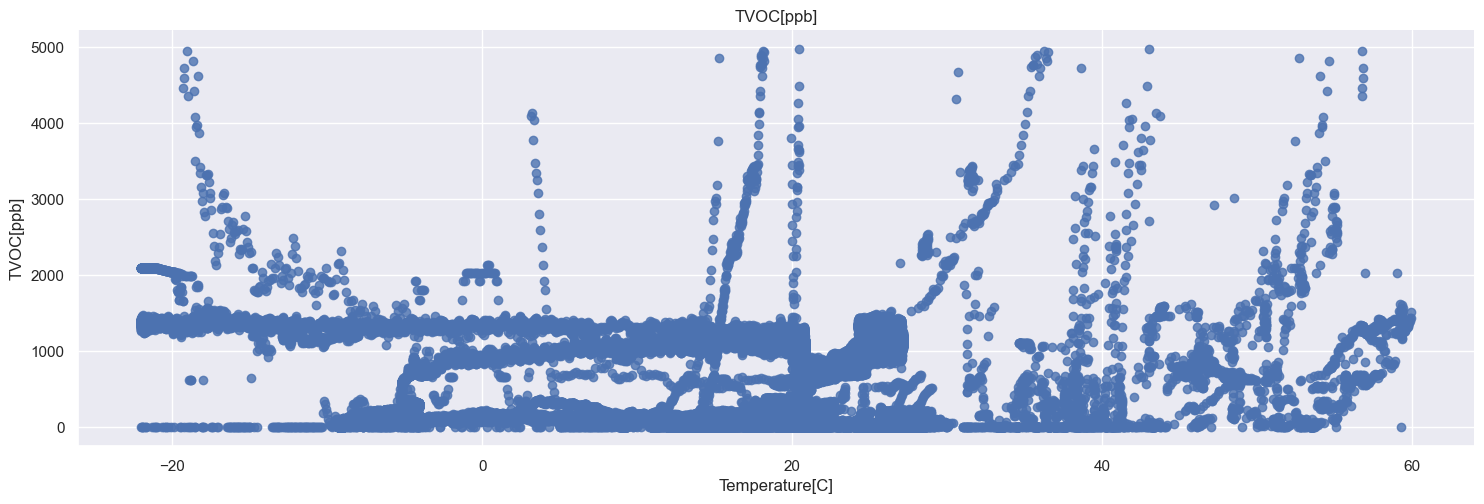

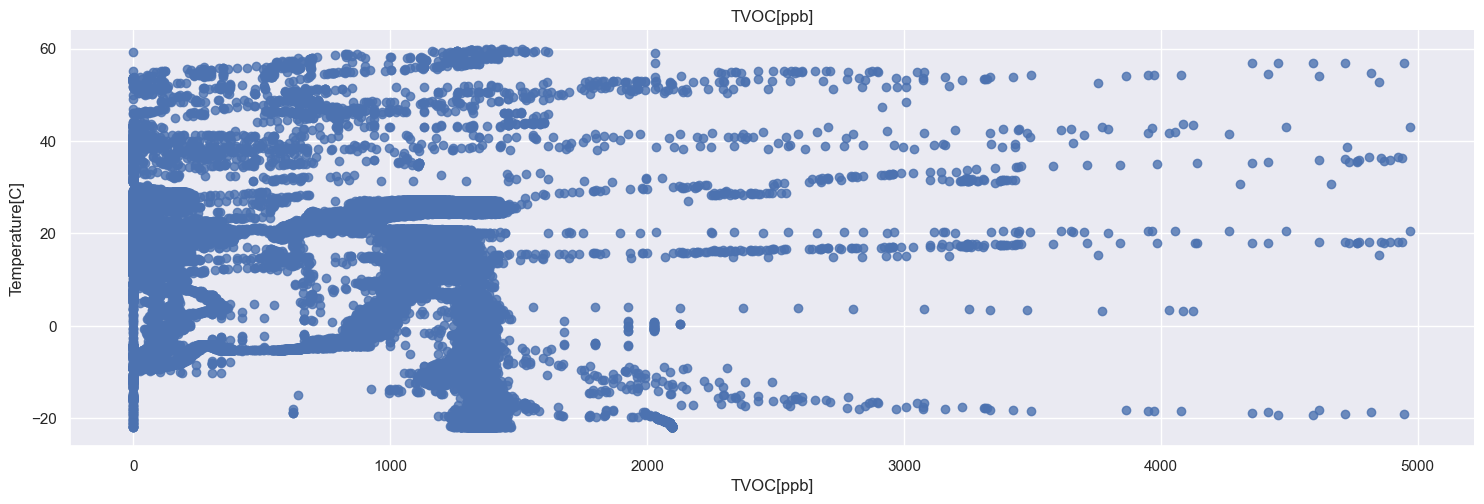

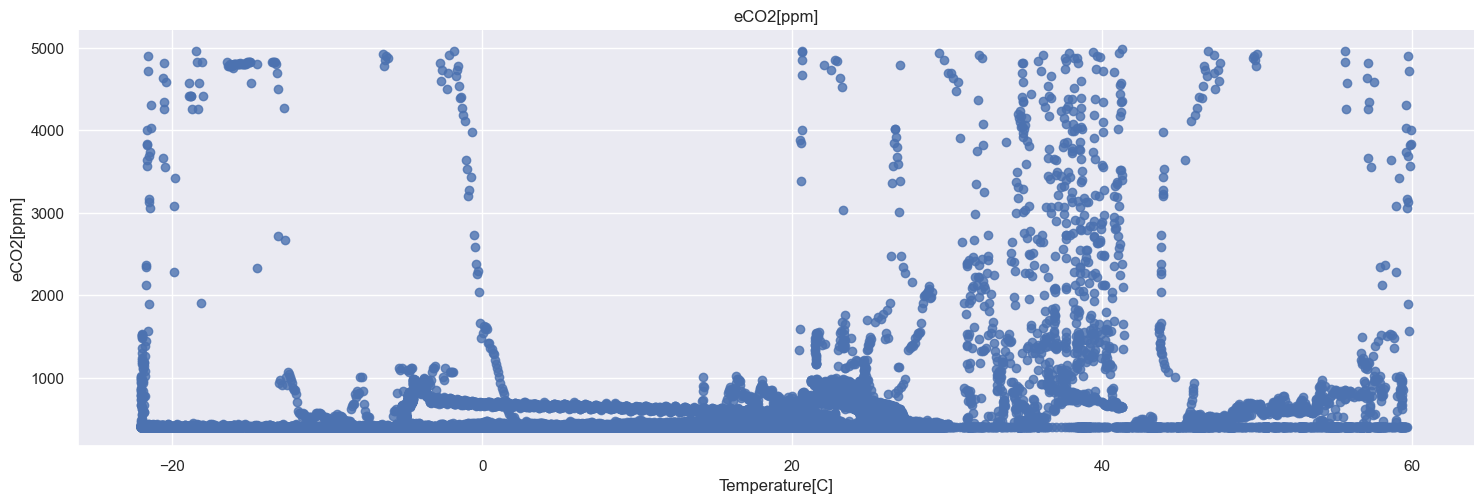

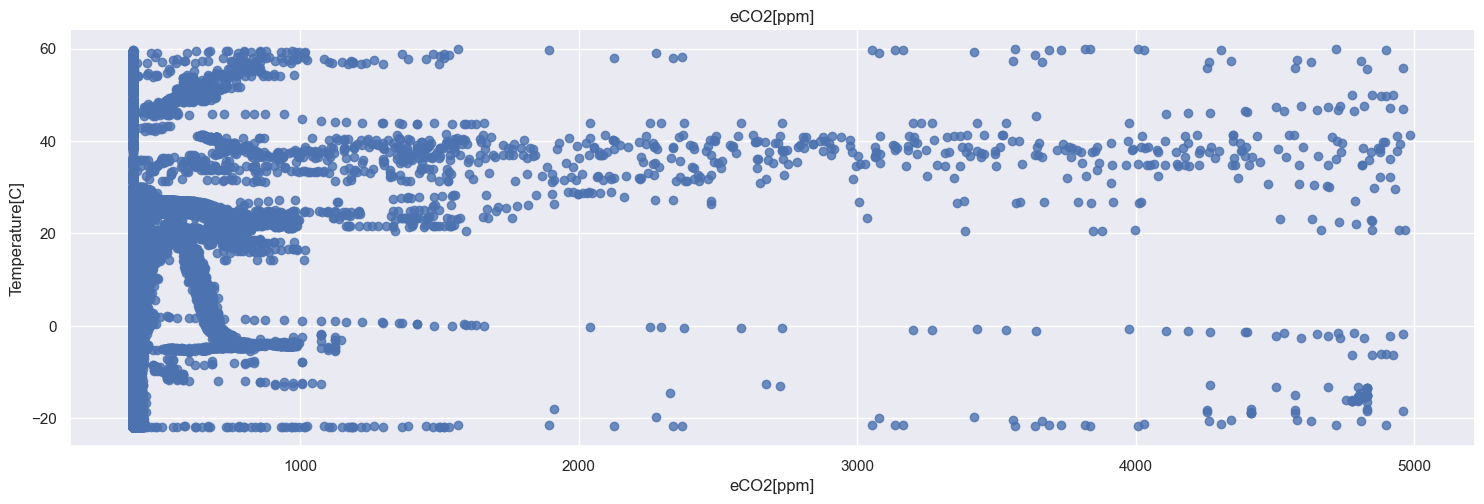

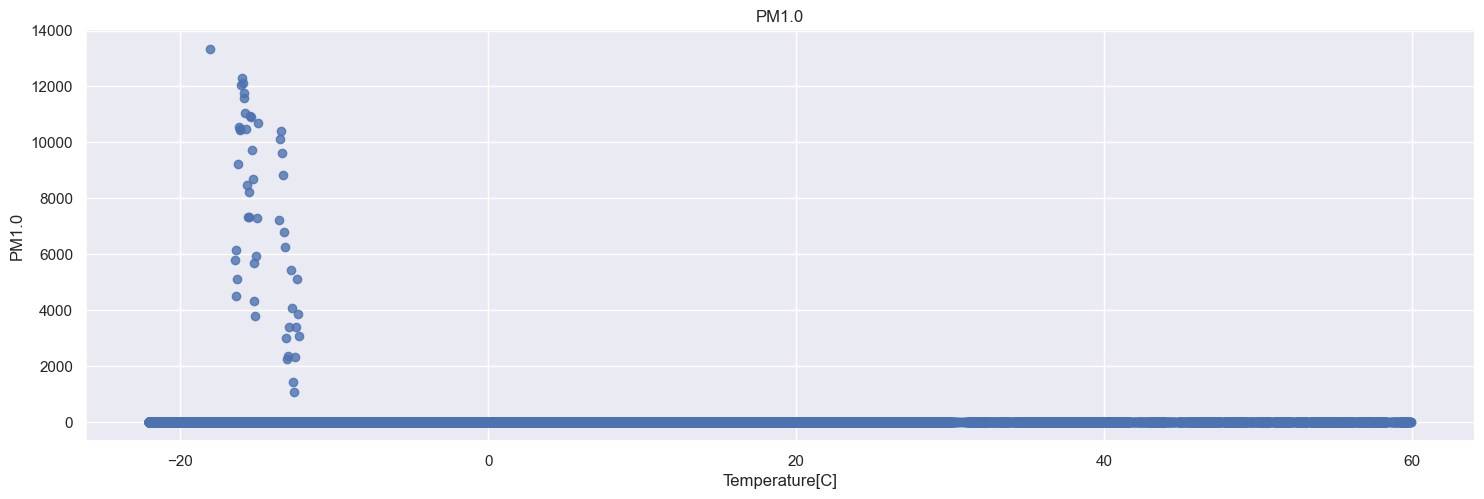

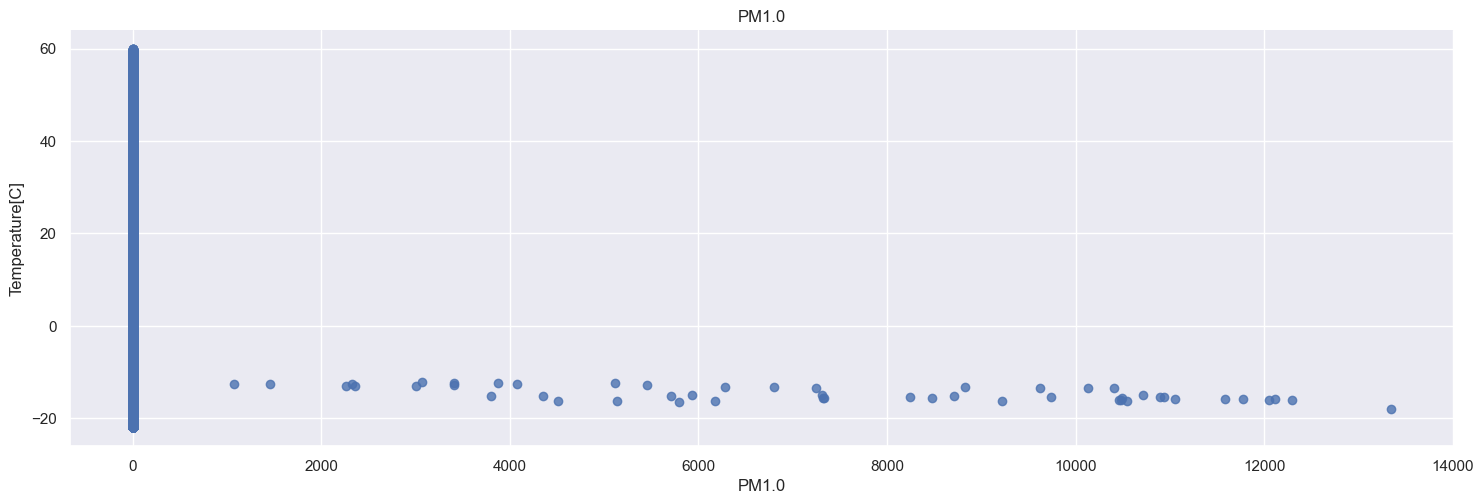

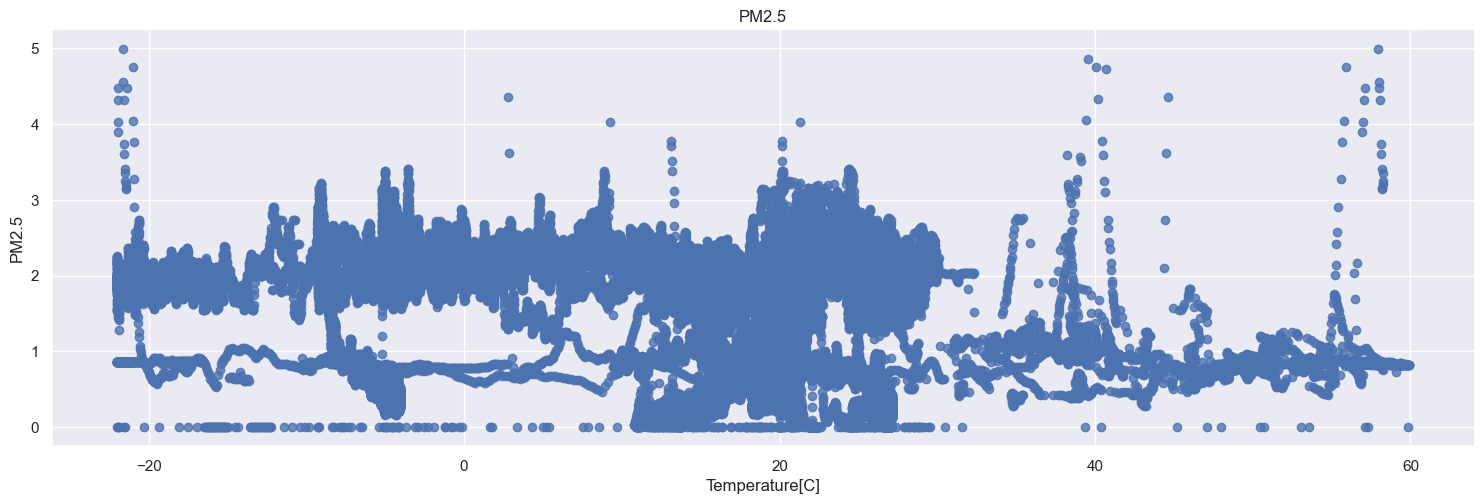

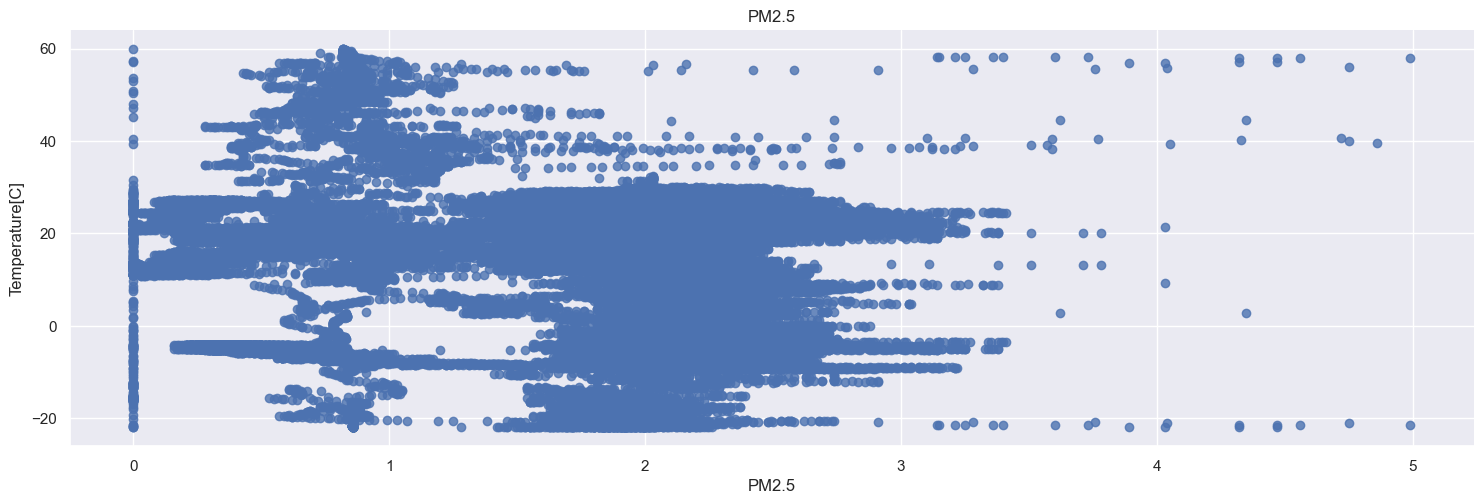

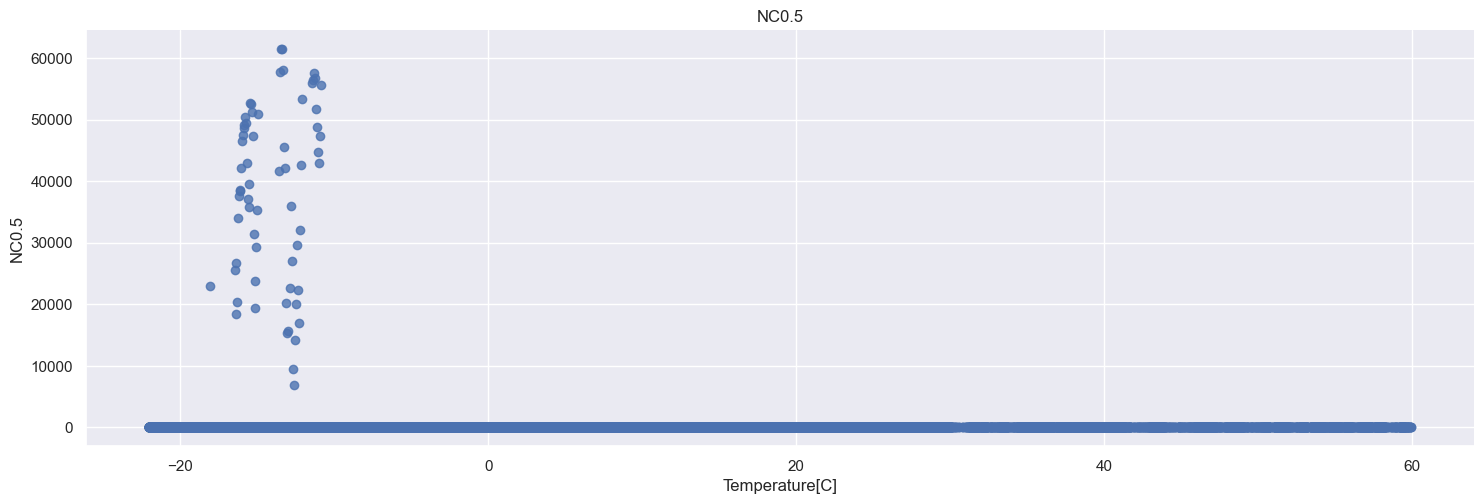

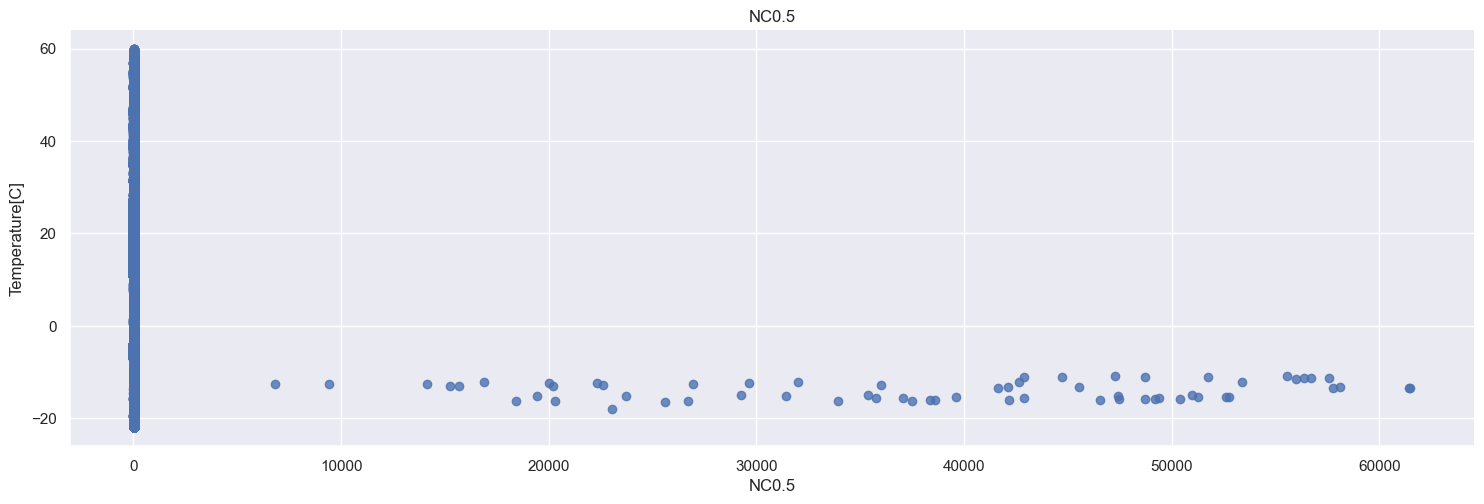

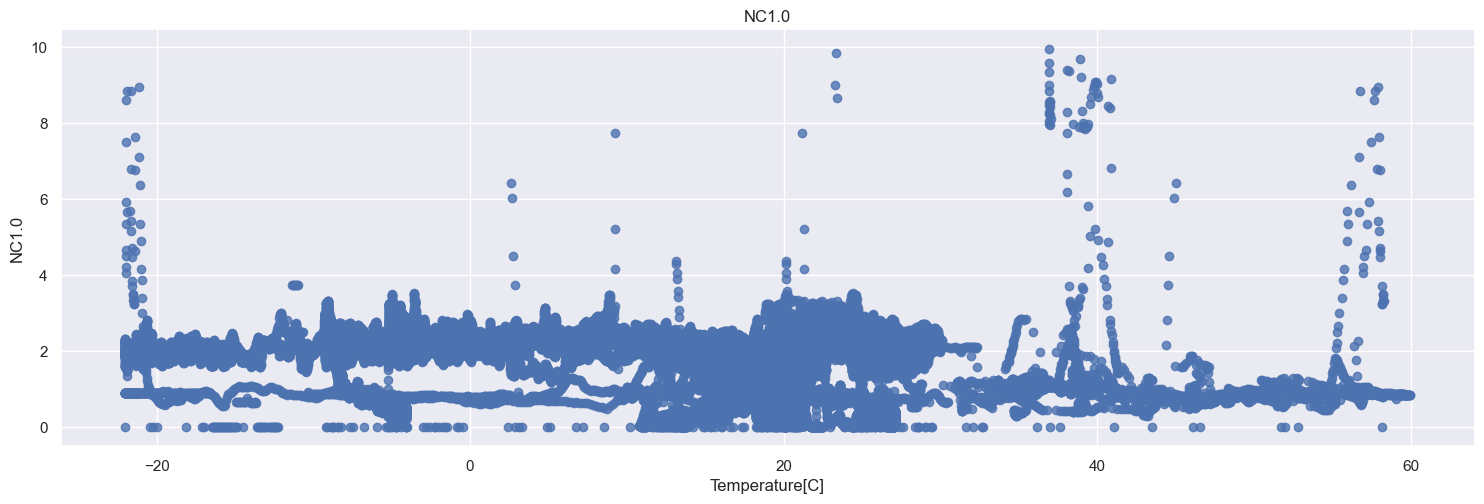

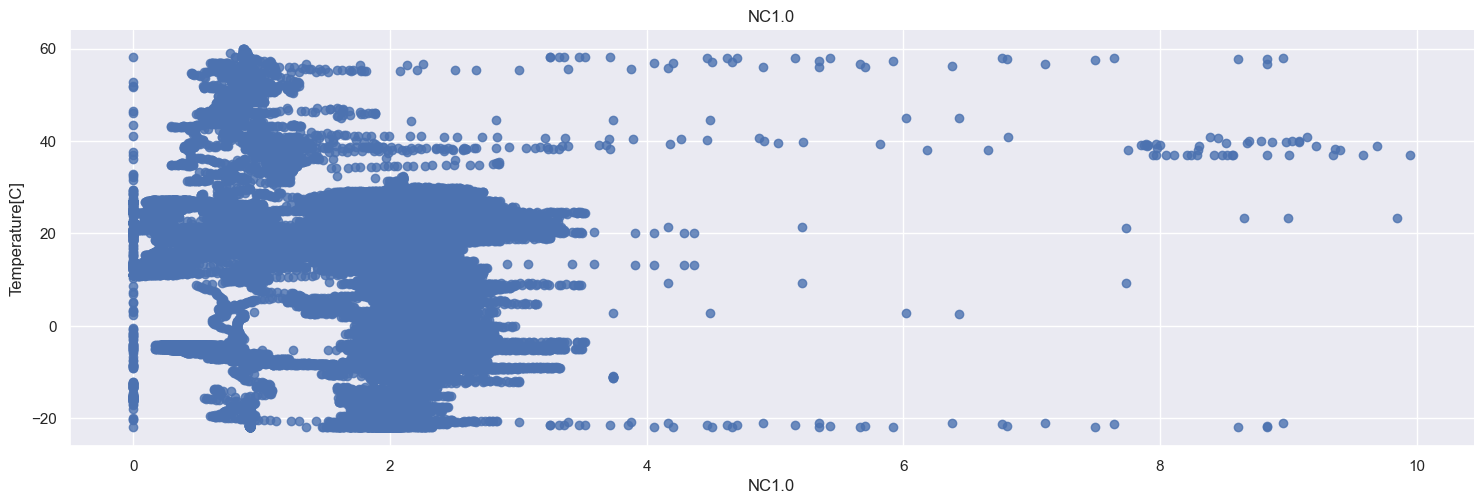

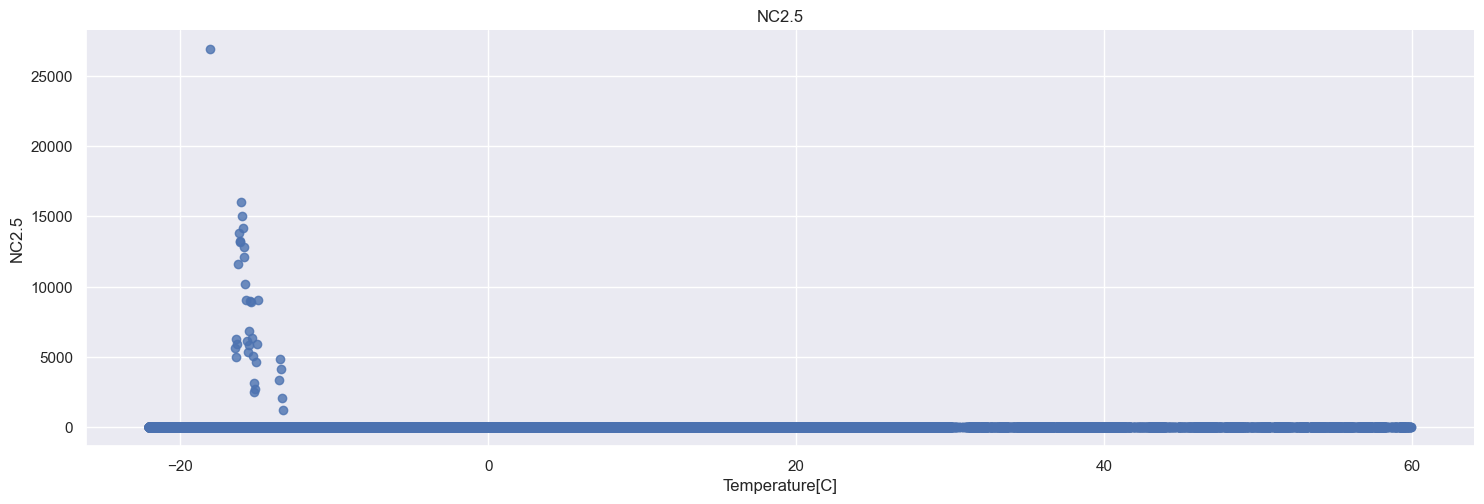

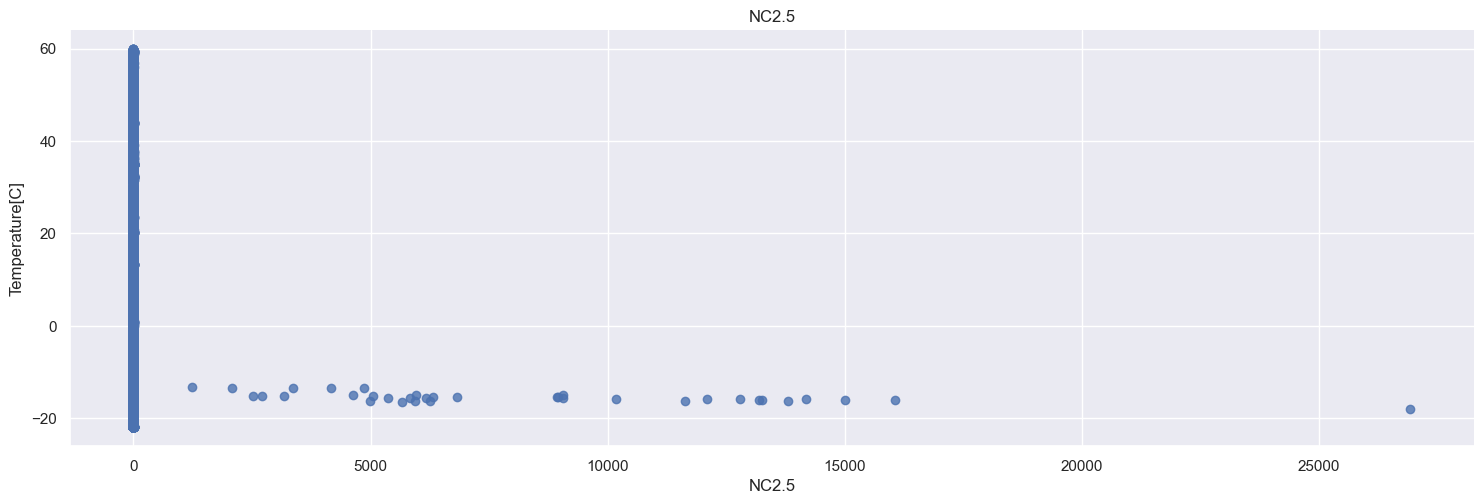

In [138]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=data, height = 5, aspect =3, fit_reg=False)
    plt.title(column)
    sns.lmplot(x=column, y="Temperature[C]", data=data, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

In [139]:
data = data[(data["PM1.0"] < 5) & (data["PM2.5"] < 5) & (data["NC0.5"] < 20) & (data["NC1.0"] < 10) & (data["NC2.5"] < 5)]

In [140]:
fire_alarm_true = data[data["Fire Alarm"] == True]
fire_alarm_false = data[data["Fire Alarm"] == False]

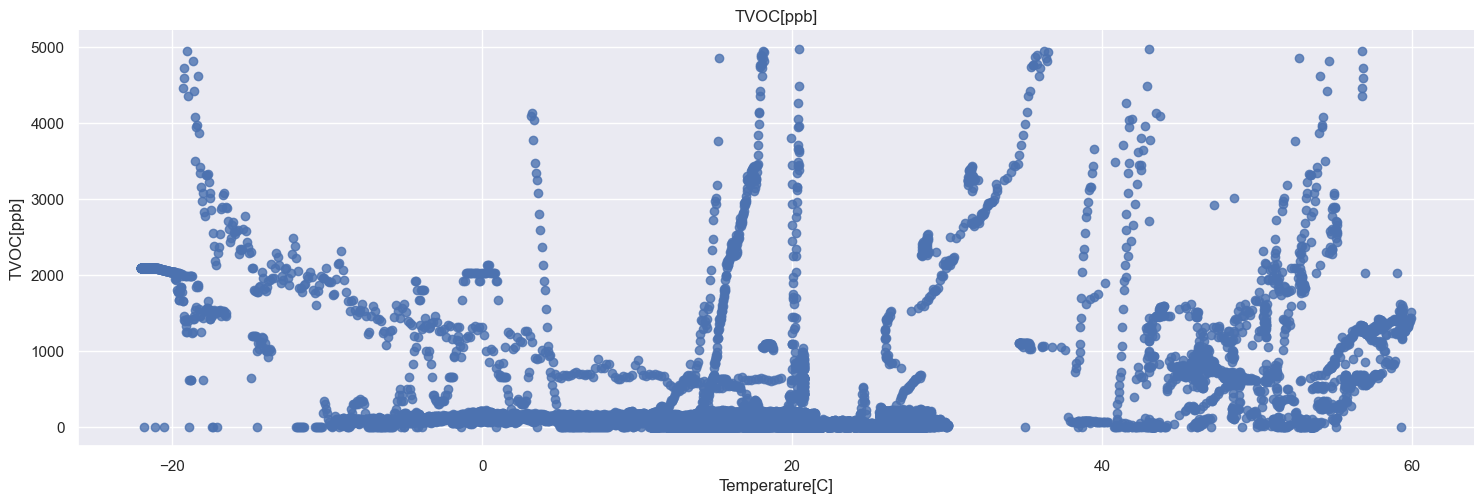

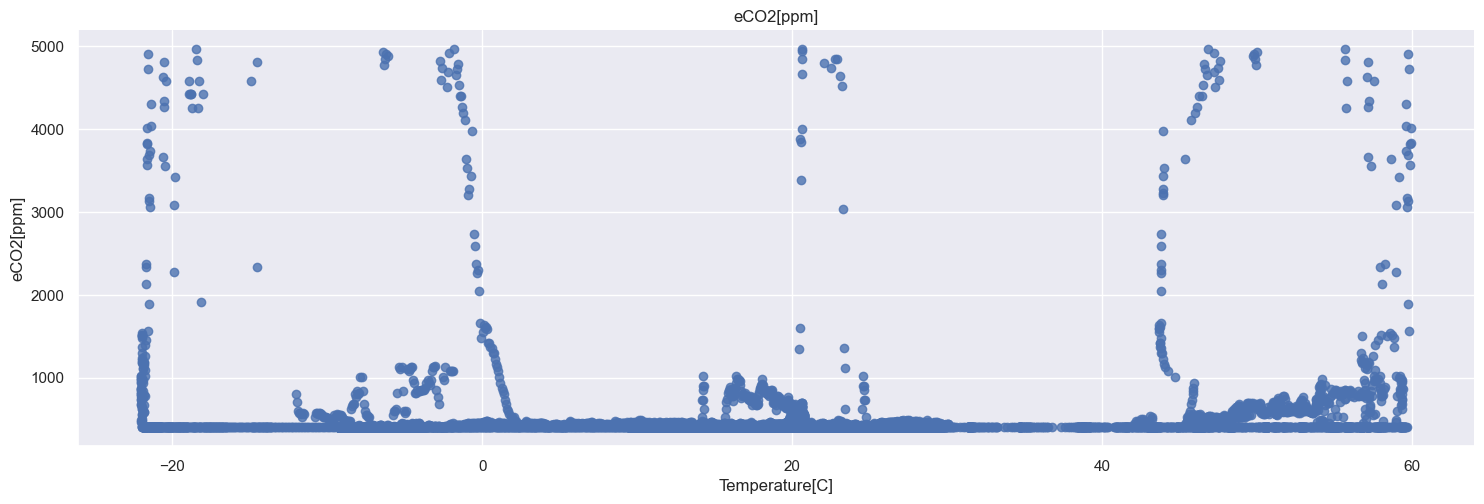

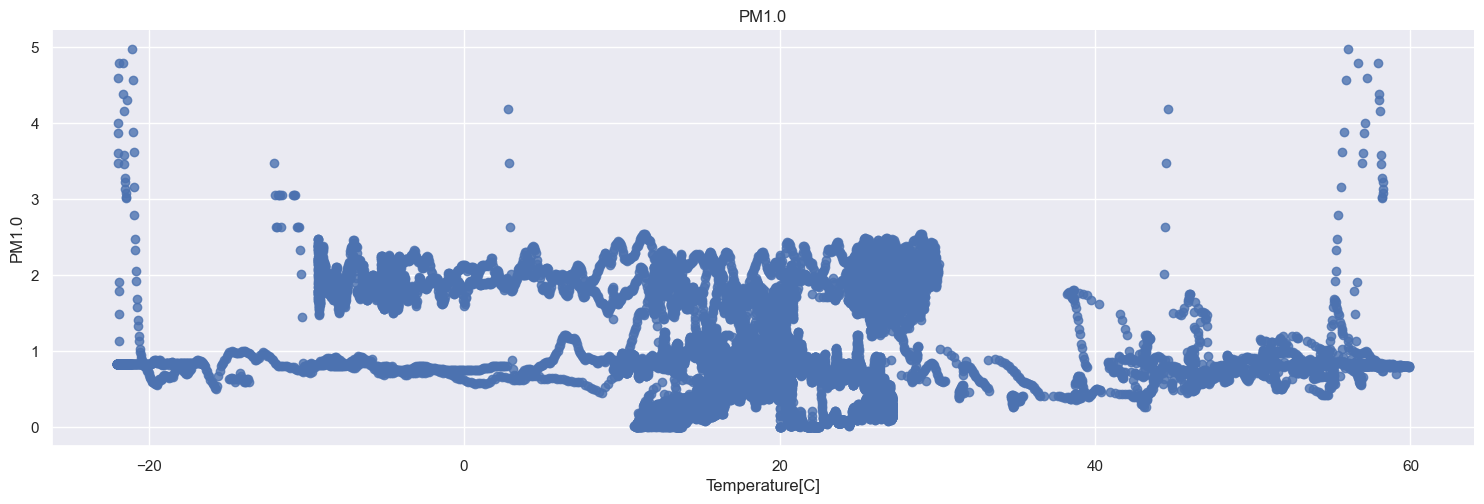

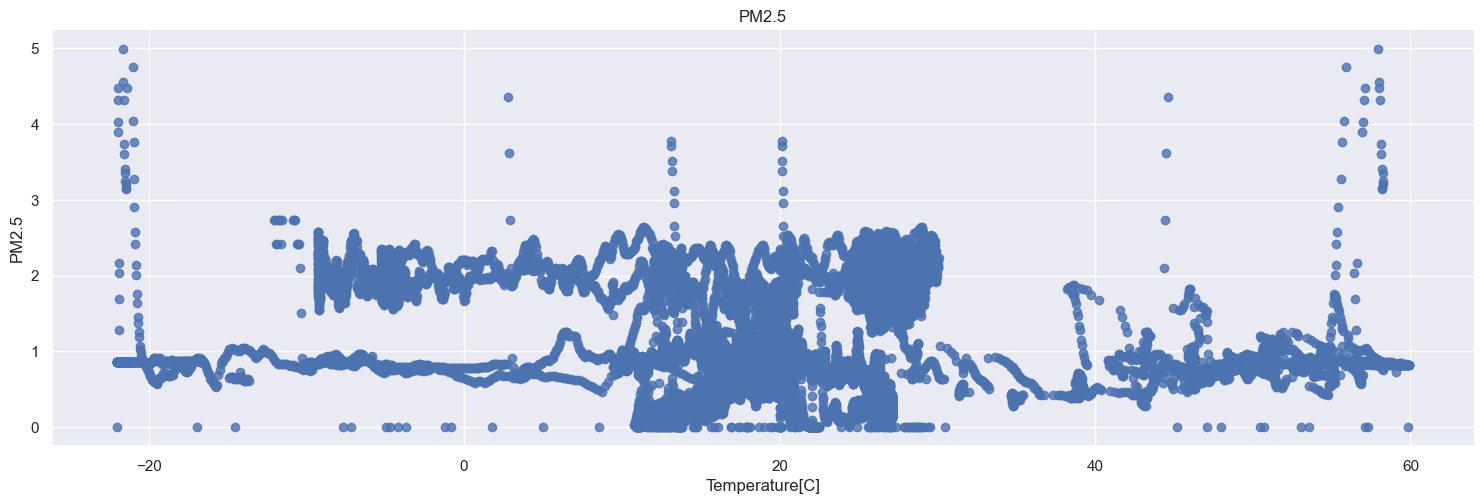

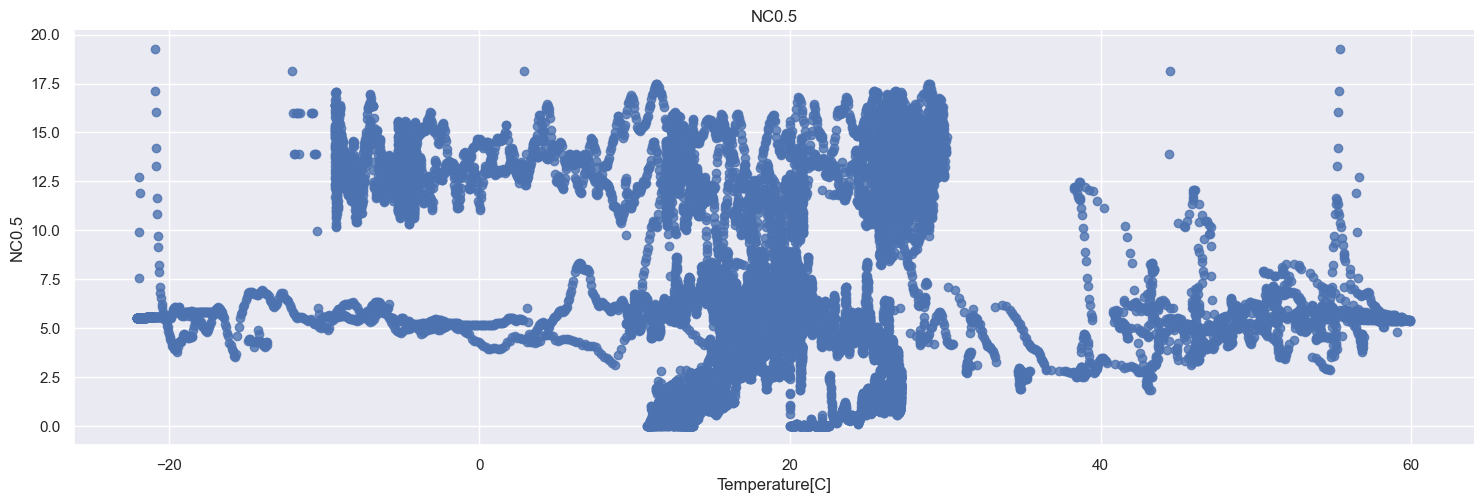

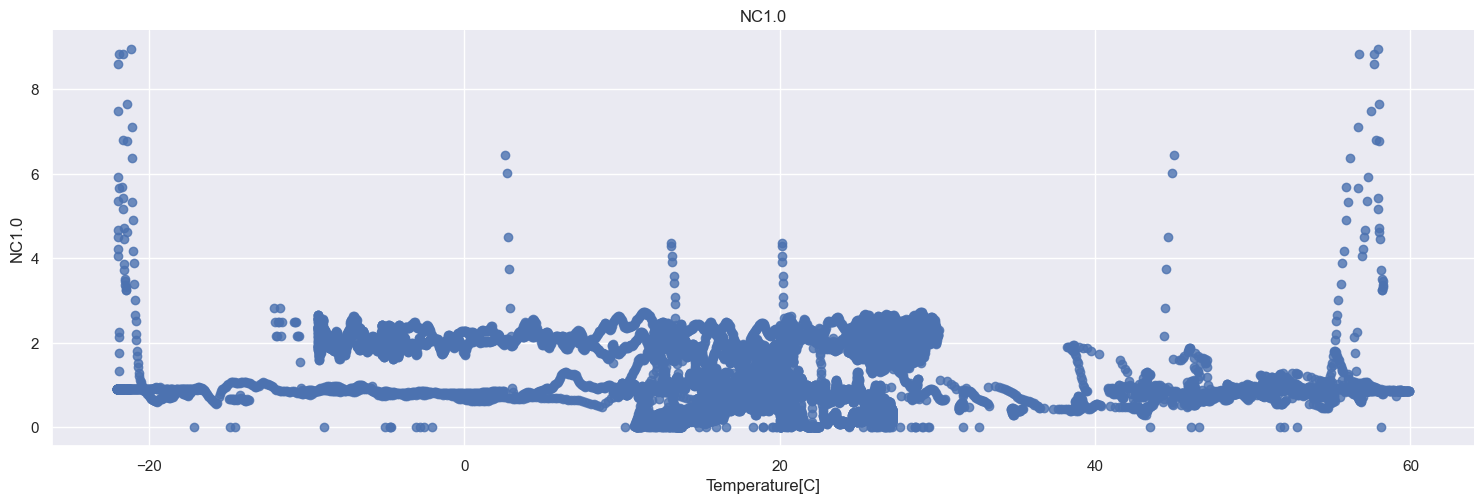

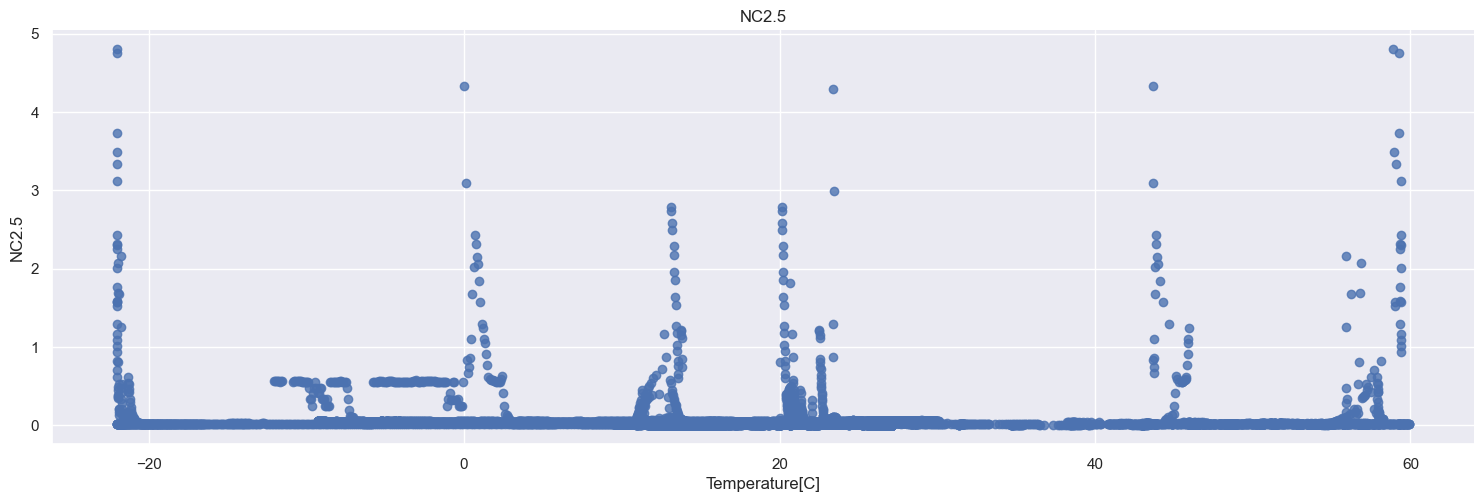

In [141]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=fire_alarm_false, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

In [142]:
emissions_false = {
    "TVOC[ppb]": 1000,
    "eCO2[ppm]": 1200,
    "PM1.0": 2,
    "PM2.5": 3.5,
    "NC0.5": 3,
    "NC1.0": 1,
    "NC2.5": 0.5,
}

In [143]:
data_true = data[data["Fire Alarm"] == True]
data_false = data[(data["Fire Alarm"] == False) & (data["TVOC[ppb]"] < 1000) & (data["eCO2[ppm]"] < 1200) & (data["PM1.0"] < 2) & (data["PM2.5"] < 3.5) & (data["NC0.5"] < 3) & (data["NC1.0"] < 1) & (data["NC2.5"] < 0.5)]
data = pd.concat([data_true, data_false], ignore_index=True)

In [144]:
fire_alarm_false = data[data["Fire Alarm"] == False]

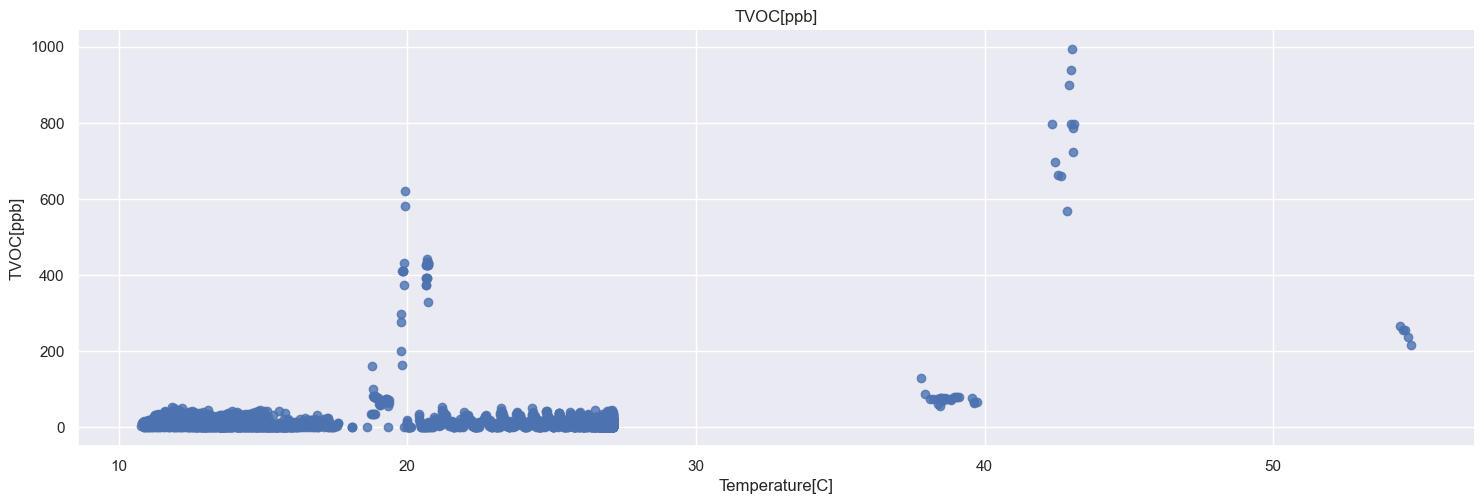

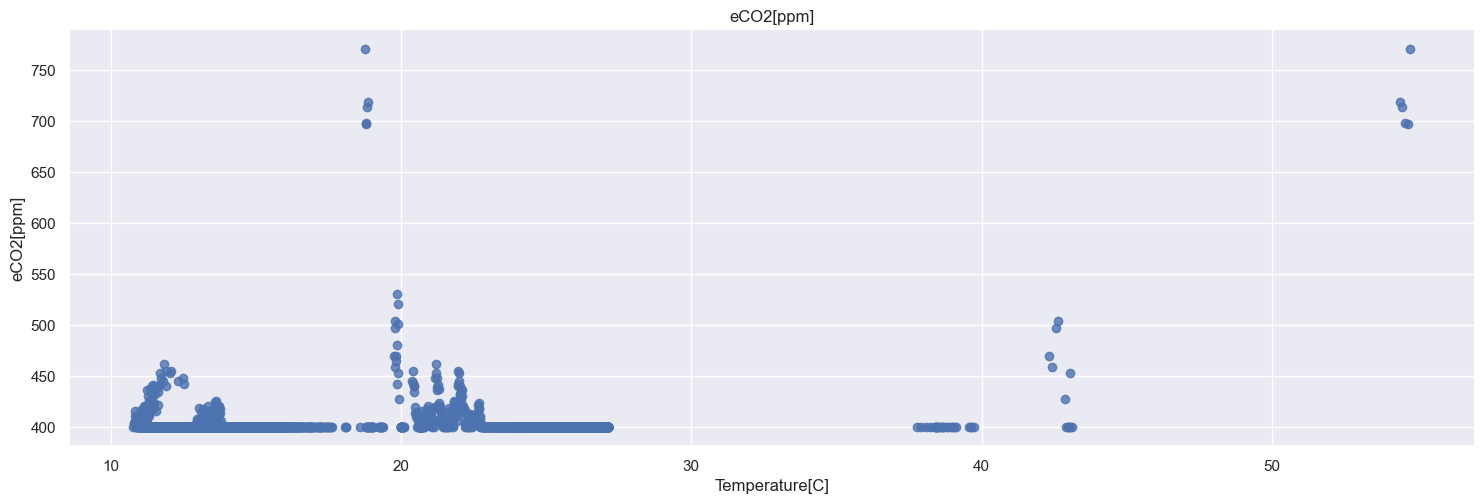

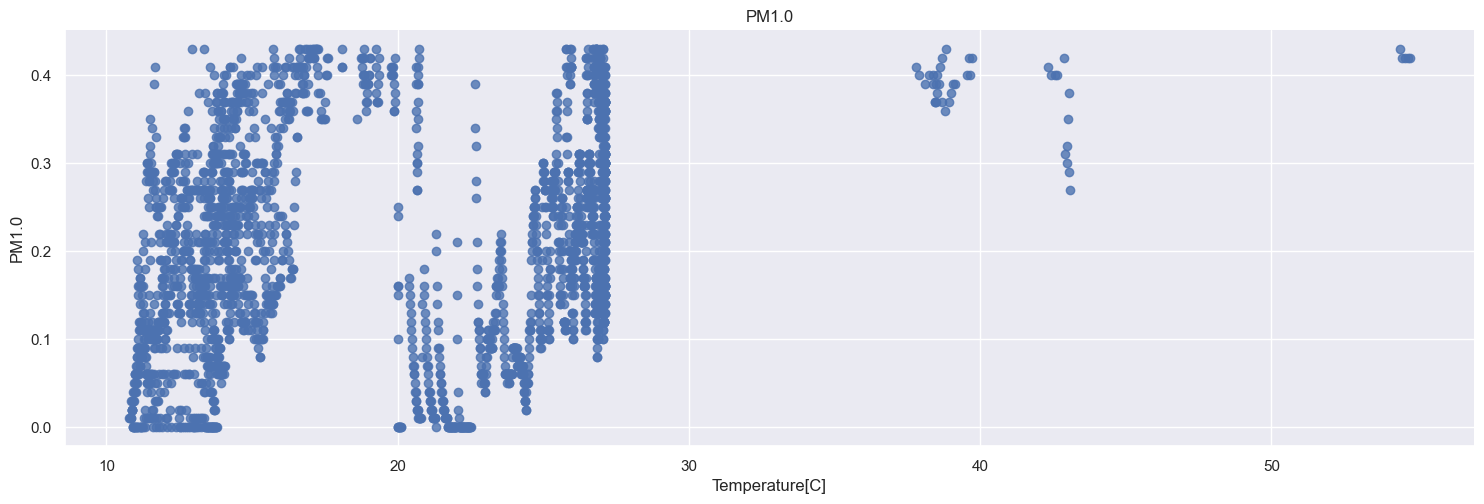

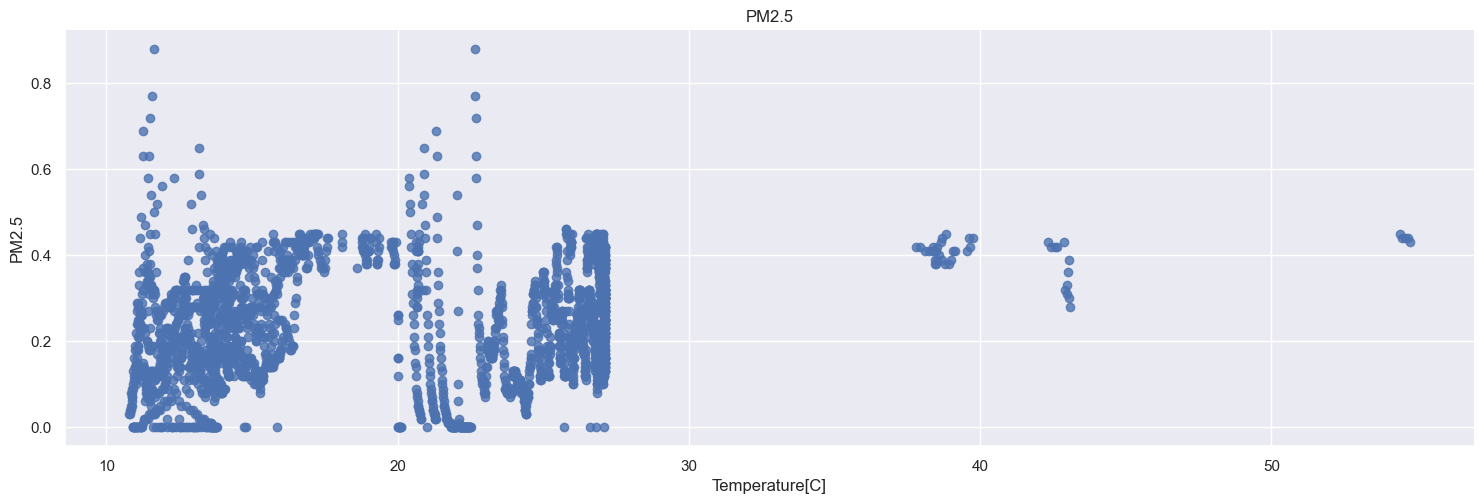

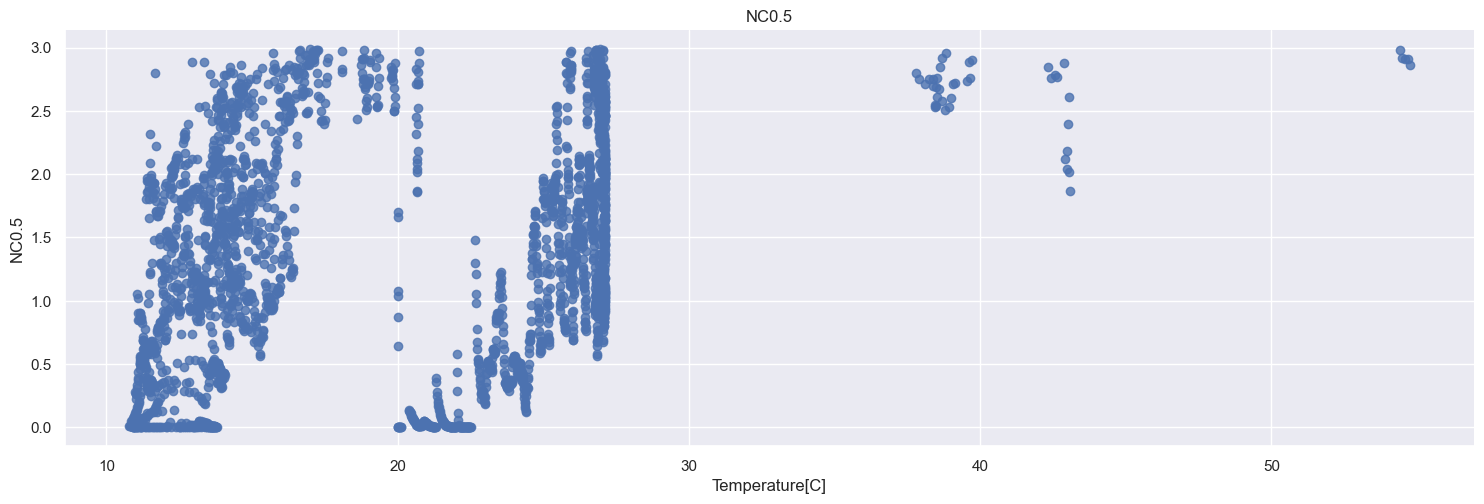

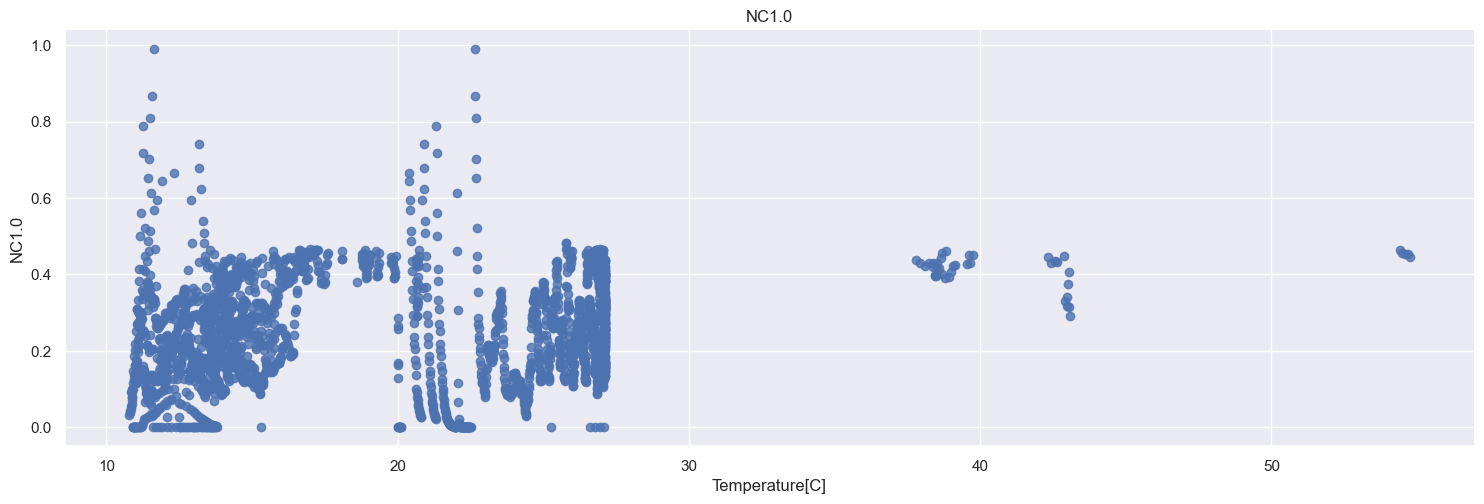

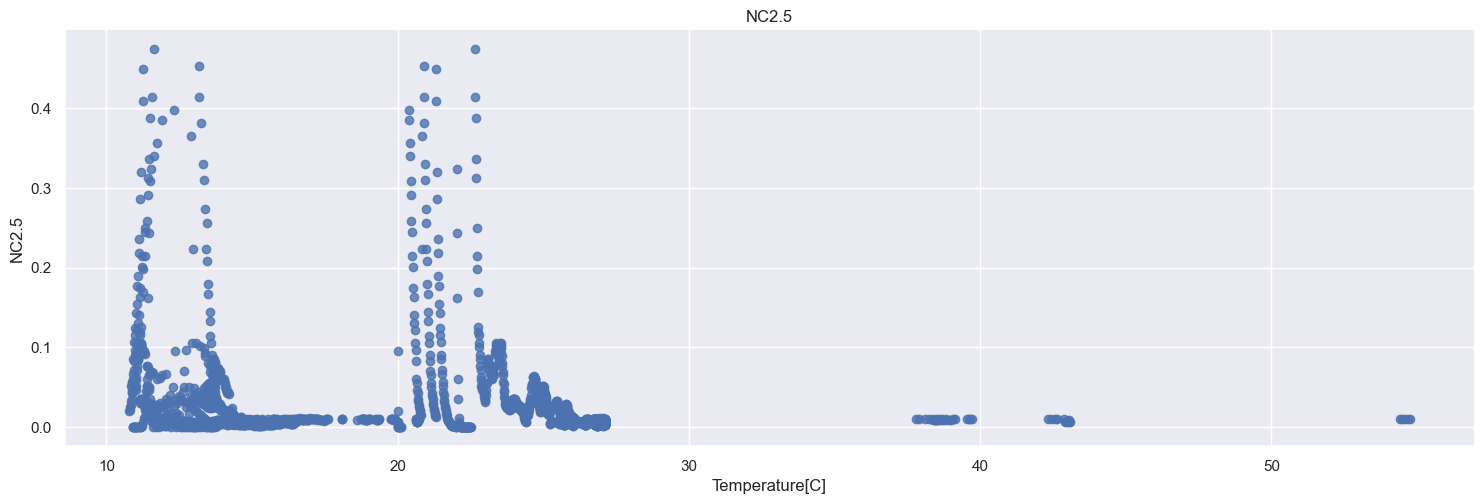

In [145]:
for column in columns:
    sns.lmplot(x="Temperature[C]", y=column, data=fire_alarm_false, height = 5, aspect =3, fit_reg=False)
    plt.title(column)

<Axes: xlabel='TVOC[ppb]', ylabel='eCO2[ppm]'>

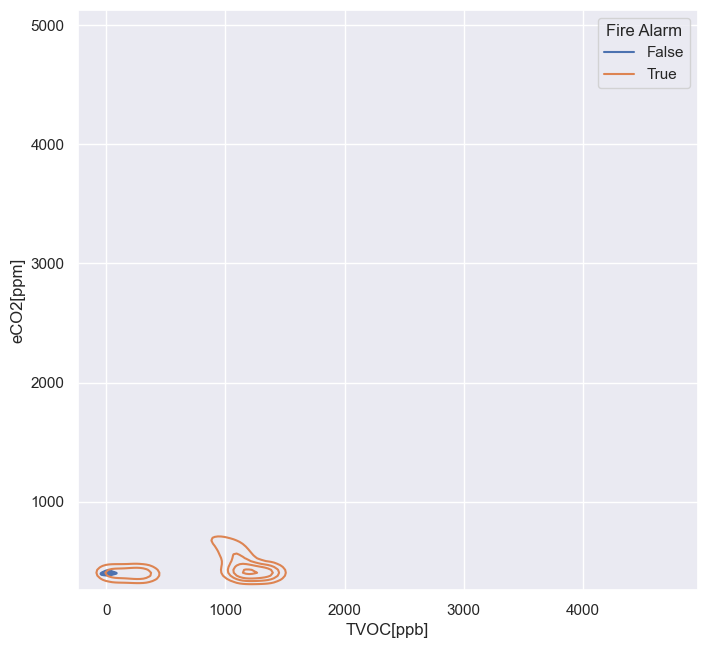

In [146]:
sns.set_theme(style="darkgrid")

f, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")

sns.kdeplot(
    data=data,
    x="TVOC[ppb]",
    y="eCO2[ppm]",
    hue="Fire Alarm",
    thresh=.1,
)